# 음악 청취 습관 기반 불안 수준 분류 모델 구축
= 팀원
- 2570355 김예진
- 2570360 이가은
- 2570363 이고은
- 2570363 이정민
- 2570372 황하진

# 0. 구글 코랩 설정

In [2]:
# from google.colab import drive
# drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
# # 0. (최초 1회) 나눔고딕 폰트 설치
# !apt-get update -qq
# !apt-get install -y fonts-nanum -qq

# # 1. 폰트 파일을 Matplotlib font manager 에 등록
# import matplotlib.pyplot as plt
# import matplotlib.font_manager as fm
# import os

# # 폰트가 설치된 경로 지정
# nanum_dir = '/usr/share/fonts/truetype/nanum'

# # 해당 폴더 내 모든 ttf 파일을 찾아 등록
# for fname in os.listdir(nanum_dir):
#     if fname.lower().endswith('.ttf'):
#         fm.fontManager.addfont(os.path.join(nanum_dir, fname))

# # 2. 한글 폰트 기본 설정
# plt.rc('font', family='NanumGothic')


W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Selecting previously unselected package fonts-nanum.
(Reading database ... 126319 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...


In [4]:
# !pip install scikit-learn

In [5]:
# pip install imbalanced-learn

In [6]:
# pip install lightgbm catboost imbalanced-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 7.4 MB/s eta 0:00:00


# 1. 데이터 로드 및 결측치 확인

In [7]:
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/hywu/빅데이터모델링/팀프로젝트/mxmh_survey_results.csv')
df.head(15)

,Timestamp,Age,Primary streaming service,Hours per day,While working,Instrumentalist,Composer,Fav genre,Exploratory,Foreign languages,...,Frequency [R&B],Frequency [Rap],Frequency [Rock],Frequency [Video game music],Anxiety,Depression,Insomnia,OCD,Music effects,Permissions
0,8/27/2022 19:29:02,18.0,Spotify,3.0,Yes,Yes,Yes,Latin,Yes,Yes,...,Sometimes,Very frequently,Never,Sometimes,3.0,0.0,1.0,0.0,NaN,I understand.
1,8/27/2022 19:57:31,63.0,Pandora,1.5,Yes,No,No,Rock,Yes,No,...,Sometimes,Rarely,Very frequently,Rarely,7.0,2.0,2.0,1.0,NaN,I understand.
2,8/27/2022 21:28:18,18.0,Spotify,4.0,No,No,No,Video game music,No,Yes,...,Never,Rarely,Rarely,Very frequently,7.0,7.0,10.0,2.0,No effect,I understand.
3,8/27/2022 21:40:40,61.0,YouTube Music,2.5,Yes,No,Yes,Jazz,Yes,Yes,...,Sometimes,Never,Never,Never,9.0,7.0,3.0,3.0,Improve,I understand.
4,8/27/2022 21:54:47,18.0,Spotify,4.0,Yes,No,No,R&B,Yes,No,...,Very frequently,Very frequently,Never,Rarely,7.0,2.0,5.0,9.0,Improve,I understand.
5,8/27/2022 21:56:50,18.0,Spotify,5.0,Yes,Yes,Yes,Jazz,Yes,Yes,...,Very frequently,Very frequently,Very frequently,Never,8.0,8.0,7.0,7.0,Improve,I understand.
6,8/27/2022 22:00:29,18.0,YouTube Music,3.0,Yes,Yes,No,Video game music,Yes,Yes,...,Rarely,Never,Never,Sometimes,4.0,8.0,6.0,0.0,Improve,I understand.
7,8/27/2022 22:18:59,21.0,Spotify,1.0,Yes,No,No,K pop,Yes,Yes,...,Sometimes,Rarely,Never,Rarely,5.0,3.0,5.0,3.0,Improve,I understand.
8,8/27/2022 22:33:05,19.0,Spotify,6.0,Yes,No,No,Rock,No,No,...,Never,Never,Very frequently,Never,2.0,0.0,0.0,0.0,Improve,I understand.
9,8/27/2022 22:44:03,18.0,I do not use a streaming service.,1.0,Yes,No,No,R&B,Yes,Yes,...,Sometimes,Rarely,Sometimes,Sometimes,2.0,2.0,5.0,1.0,Improve,I understand.


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 736 entries, 0 to 735
Data columns (total 33 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Timestamp                     736 non-null    object 
 1   Age                           735 non-null    float64
 2   Primary streaming service     735 non-null    object 
 3   Hours per day                 736 non-null    float64
 4   While working                 733 non-null    object 
 5   Instrumentalist               732 non-null    object 
 6   Composer                      735 non-null    object 
 7   Fav genre                     736 non-null    object 
 8   Exploratory                   736 non-null    object 
 9   Foreign languages             732 non-null    object 
 10  BPM                           629 non-null    float64
 11  Frequency [Classical]         736 non-null    object 
 12  Frequency [Country]           736 non-null    object 
 13  Frequ

In [9]:
df.isnull().sum()

,0
Timestamp,0
Age,1
Primary streaming service,1
Hours per day,0
While working,3
Instrumentalist,4
Composer,1
Fav genre,0
Exploratory,0
Foreign languages,4


- 전처리 전 박스플롯

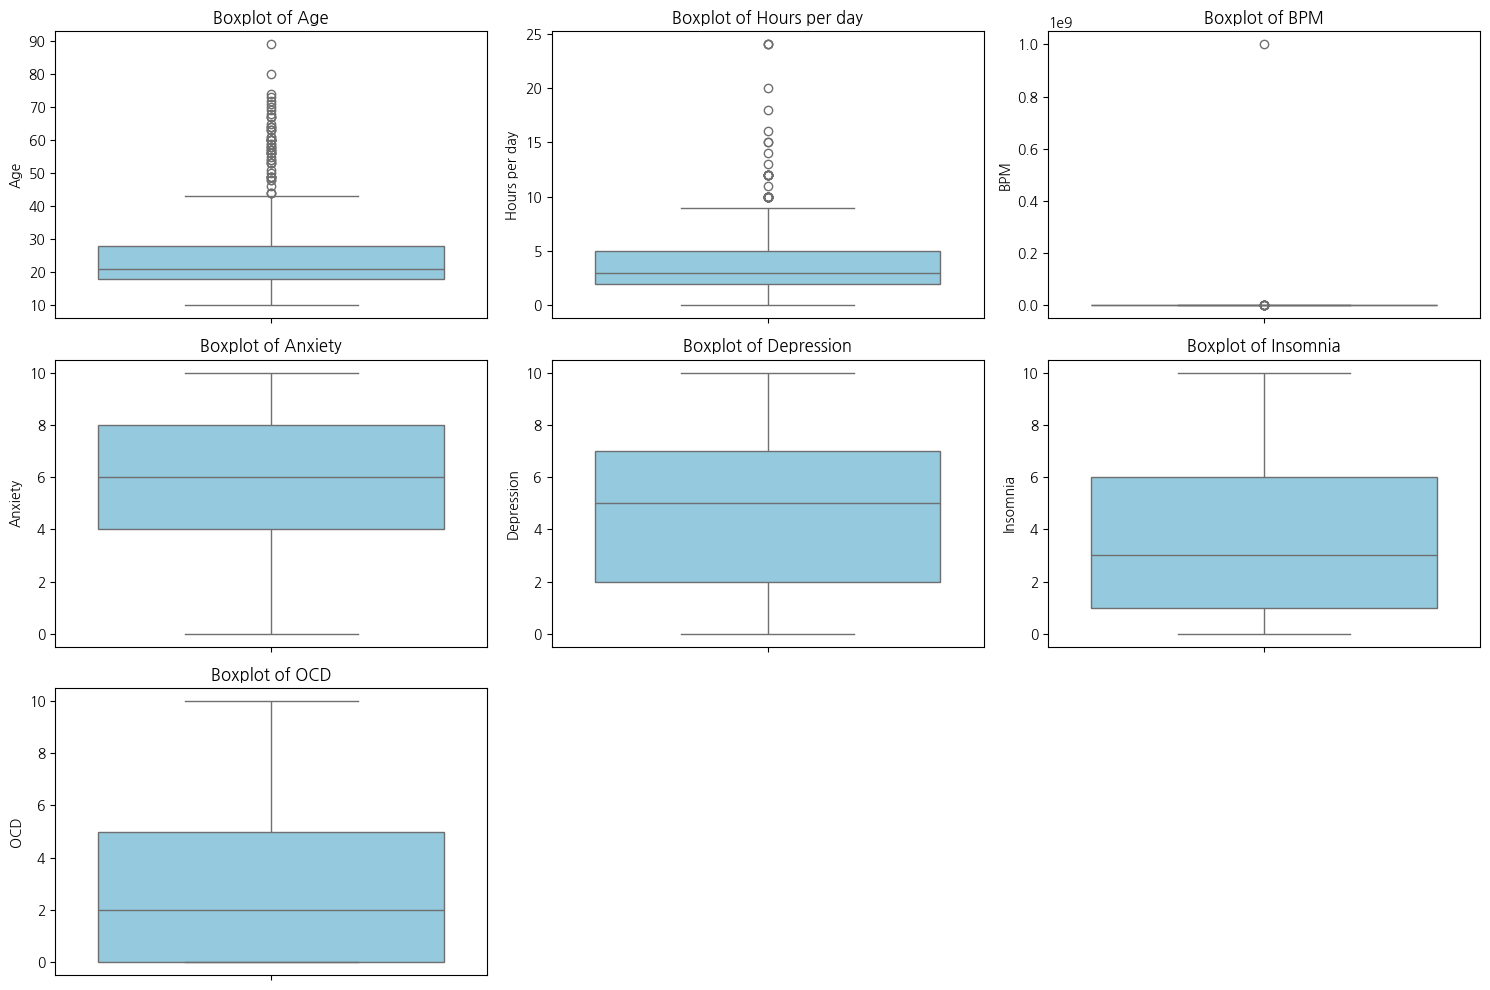

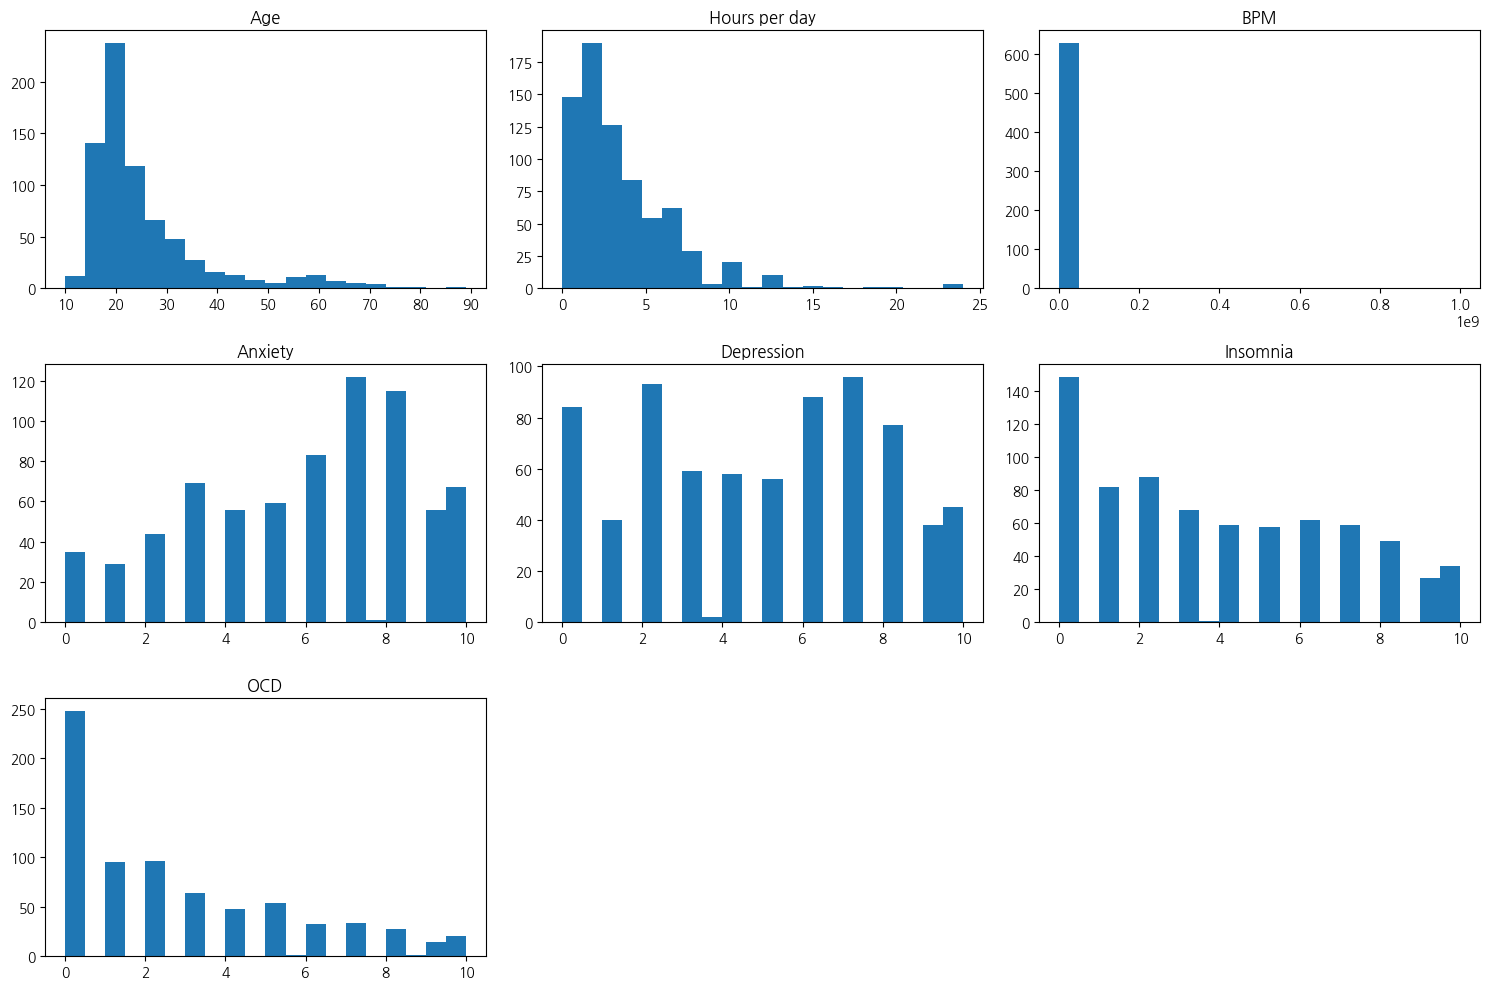

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
def plot_outliers(df):
    num_cols = ['Age', 'Hours per day', 'BPM', 'Anxiety', 'Depression', 'Insomnia', 'OCD']
    plt.figure(figsize=(15, 10))
    for i, col in enumerate(num_cols):
        plt.subplot(3, 3, i+1)
        sns.boxplot(y=df[col], color='skyblue')
        plt.title(f'Boxplot of {col}')
    plt.tight_layout()
    plt.show()
    df[num_cols].hist(figsize=(15, 10), bins=20, grid=False)
    plt.tight_layout()
    plt.show()

plot_outliers(df)

# 2. 결측치와 이상치 처리

In [11]:
# [Timestamp]설문시간, [Permissions]데이터사용동의여부 컬럼 지우기

In [12]:
df.drop(columns=['Timestamp', 'Permissions'], inplace=True)

In [13]:
# 수치형 결측치 처리
# 음악 장르별로 BPM의 평균 계산 후 해당 장르에 속하는 BPM 결측치를 평균으로 채워넣기
# Age는 중앙값

In [14]:
df['BPM'] = df.groupby('Fav genre')['BPM'].transform(lambda x: x.fillna(x.mean()))
df['Age'].fillna(df['Age'].median(), inplace=True)

/tmp/ipython-input-14-459048762.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)


In [15]:
# 최빈값으로 범주형 결측치 처리

In [16]:
categorical_cols = ['Music effects', 'Foreign languages', 'Composer',
                    'Instrumentalist', 'While working', 'Primary streaming service']

for col in categorical_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

/tmp/ipython-input-16-2718414766.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)


In [17]:
# BPM의 이상치 처리

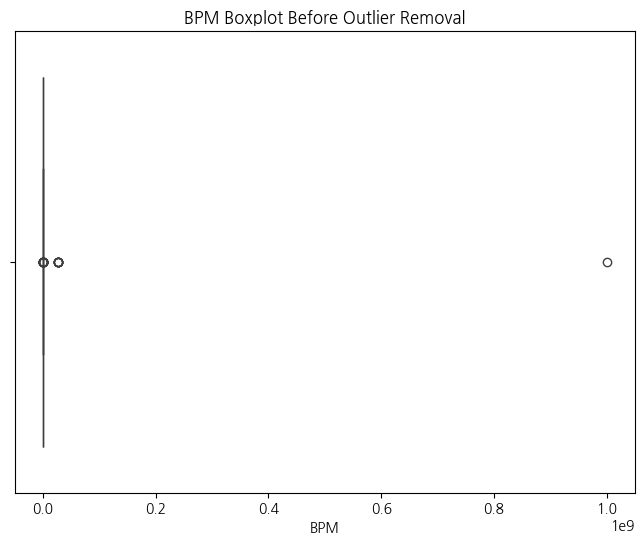

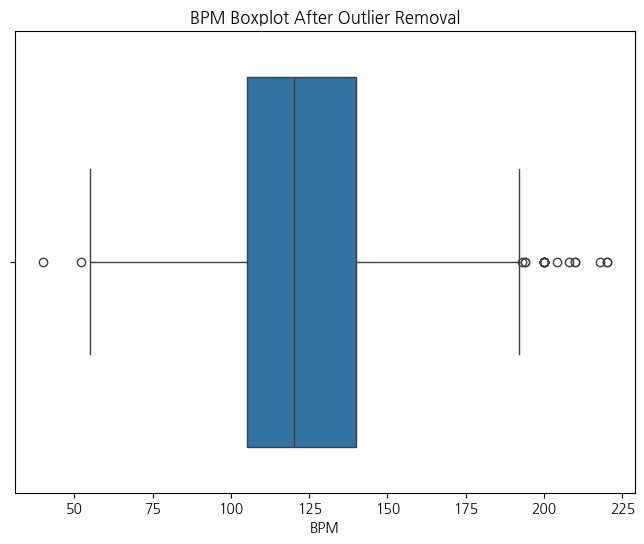

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 이상치 처리 전 BPM 박스플롯
plt.figure(figsize=(8, 6))
sns.boxplot(x=df['BPM'])
plt.title("BPM Boxplot Before Outlier Removal")
plt.show()

# 이상치 처리
df.loc[(df['BPM'] < 40) | (df['BPM'] > 220), 'BPM'] = np.nan
df['BPM'] = df['BPM'].fillna(df['BPM'].median())

# 이상치 처리 후 BPM 박스플롯
plt.figure(figsize=(8, 6))
sns.boxplot(x=df['BPM'])
plt.title("BPM Boxplot After Outlier Removal")
plt.show()

# 3. 기본 데이터셋 시각화

- 참가자 연령분포에 따른 좋아하는 음악

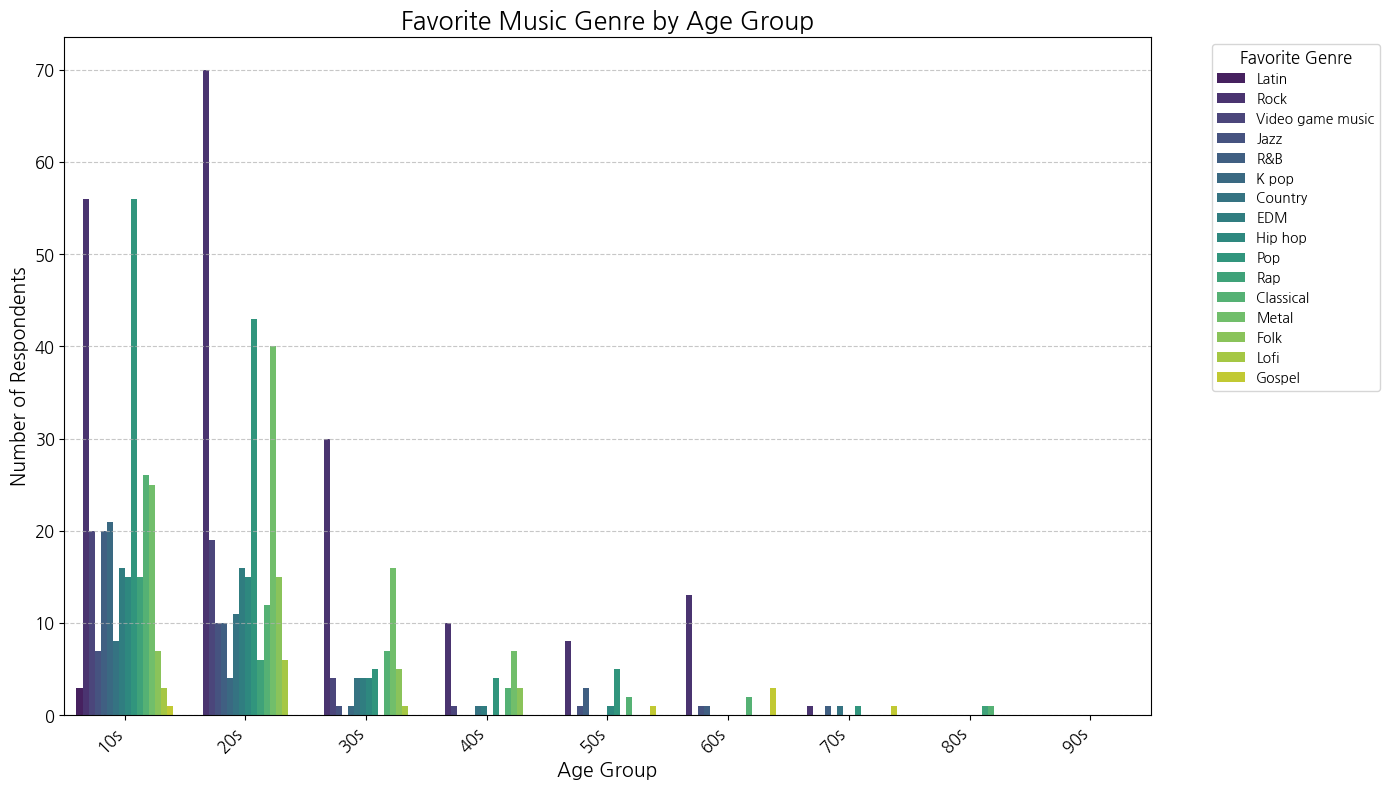

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


age_bins = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
age_labels = ['10s', '20s', '30s', '40s', '50s', '60s', '70s', '80s', '90s']
df['Age_Group'] = pd.cut(df['Age'], bins=age_bins, labels=age_labels, right=False, include_lowest=True)


if df['Age_Group'].isnull().any():
    print("Warning: Some ages fall outside defined bins or are still NaN. Filling with 'Unknown'.")
    df['Age_Group'].fillna('Unknown', inplace=True)

plt.figure(figsize=(14, 8))
sns.countplot(
    data=df,
    x='Age_Group',
    hue='Fav genre',
    palette='viridis',
    order=age_labels
)

plt.title('Favorite Music Genre by Age Group', fontsize=18)
plt.xlabel('Age Group', fontsize=14)
plt.ylabel('Number of Respondents', fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(fontsize=12)
plt.legend(title='Favorite Genre', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10, title_fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

- 가장 많이 사용하는 Primary straming service 별 응답수

/tmp/ipython-input-20-2961699346.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


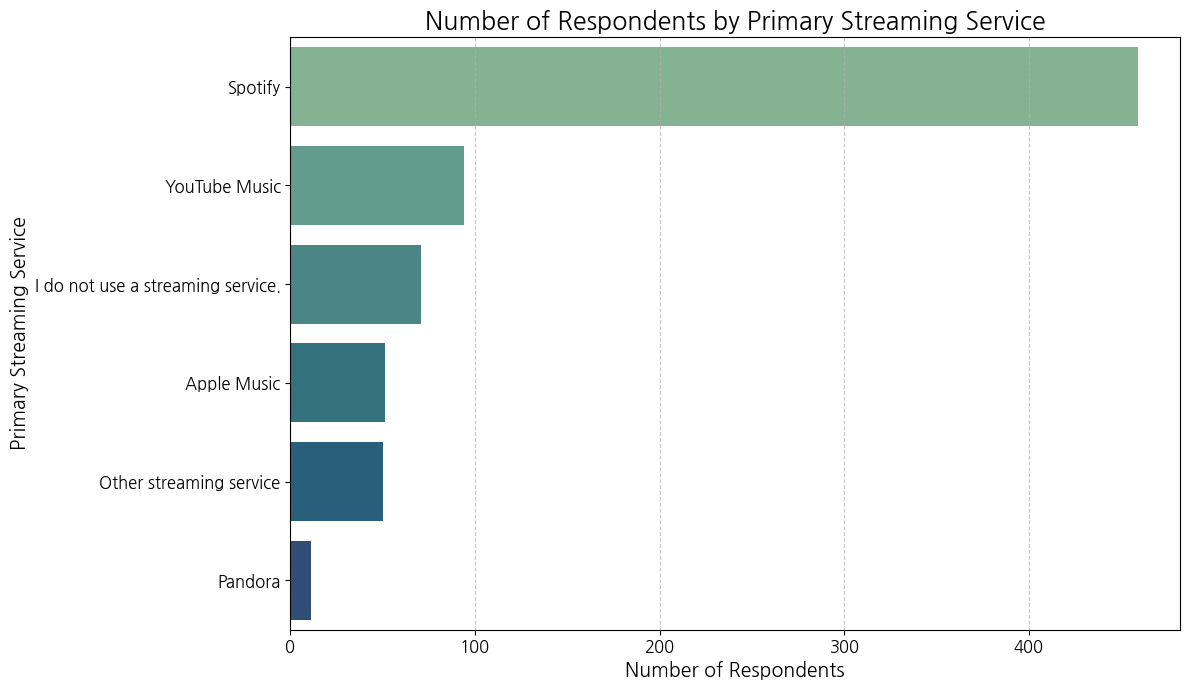

In [20]:
plt.figure(figsize=(12, 7))
sns.countplot(
    data=df,
    y='Primary streaming service',
    order=df['Primary streaming service'].value_counts().index,
    palette='crest'
)

plt.title('Number of Respondents by Primary Streaming Service', fontsize=18)
plt.xlabel('Number of Respondents', fontsize=14)
plt.ylabel('Primary Streaming Service', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

- 일일 평균 성취 시간 분포

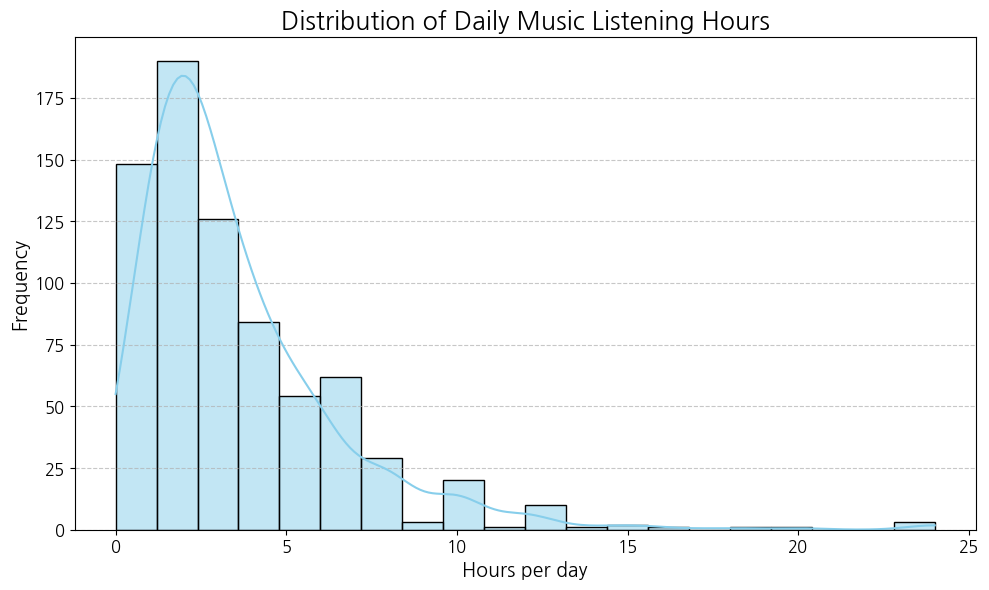

In [21]:
plt.figure(figsize=(10, 6))
sns.histplot(
    df['Hours per day'],
    bins=20,
    kde=True,
    color='skyblue',
    edgecolor='black'
)

plt.title('Distribution of Daily Music Listening Hours', fontsize=18)
plt.xlabel('Hours per day', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

- 이상치 식별 박스플롯
- 각 숫자형 열에 대한 히스토그램

In [22]:
def plot_outliers(df):
    num_cols = ['Age', 'Hours per day', 'BPM', 'Anxiety', 'Depression', 'Insomnia', 'OCD']
    plt.figure(figsize=(15, 10))
    for i, col in enumerate(num_cols):
        plt.subplot(3, 3, i+1)
        sns.boxplot(y=df[col], color='skyblue')
        plt.title(f'Boxplot of {col}')
    plt.tight_layout()
    plt.show()
    df[num_cols].hist(figsize=(15, 10), bins=20, grid=False)
    plt.tight_layout()
    plt.show()

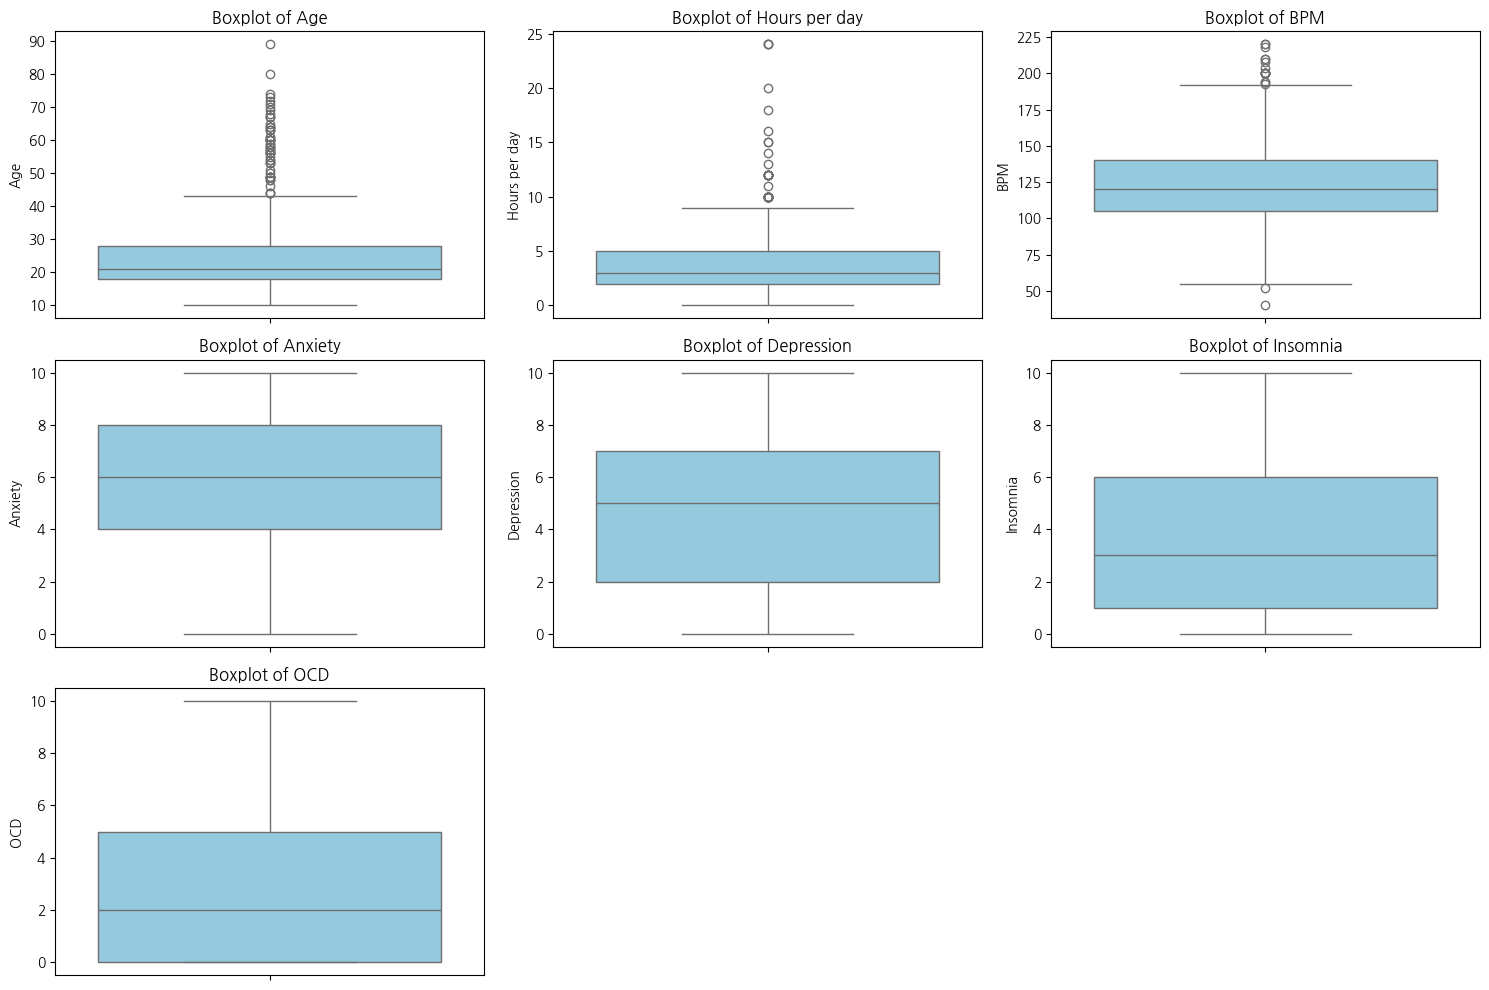

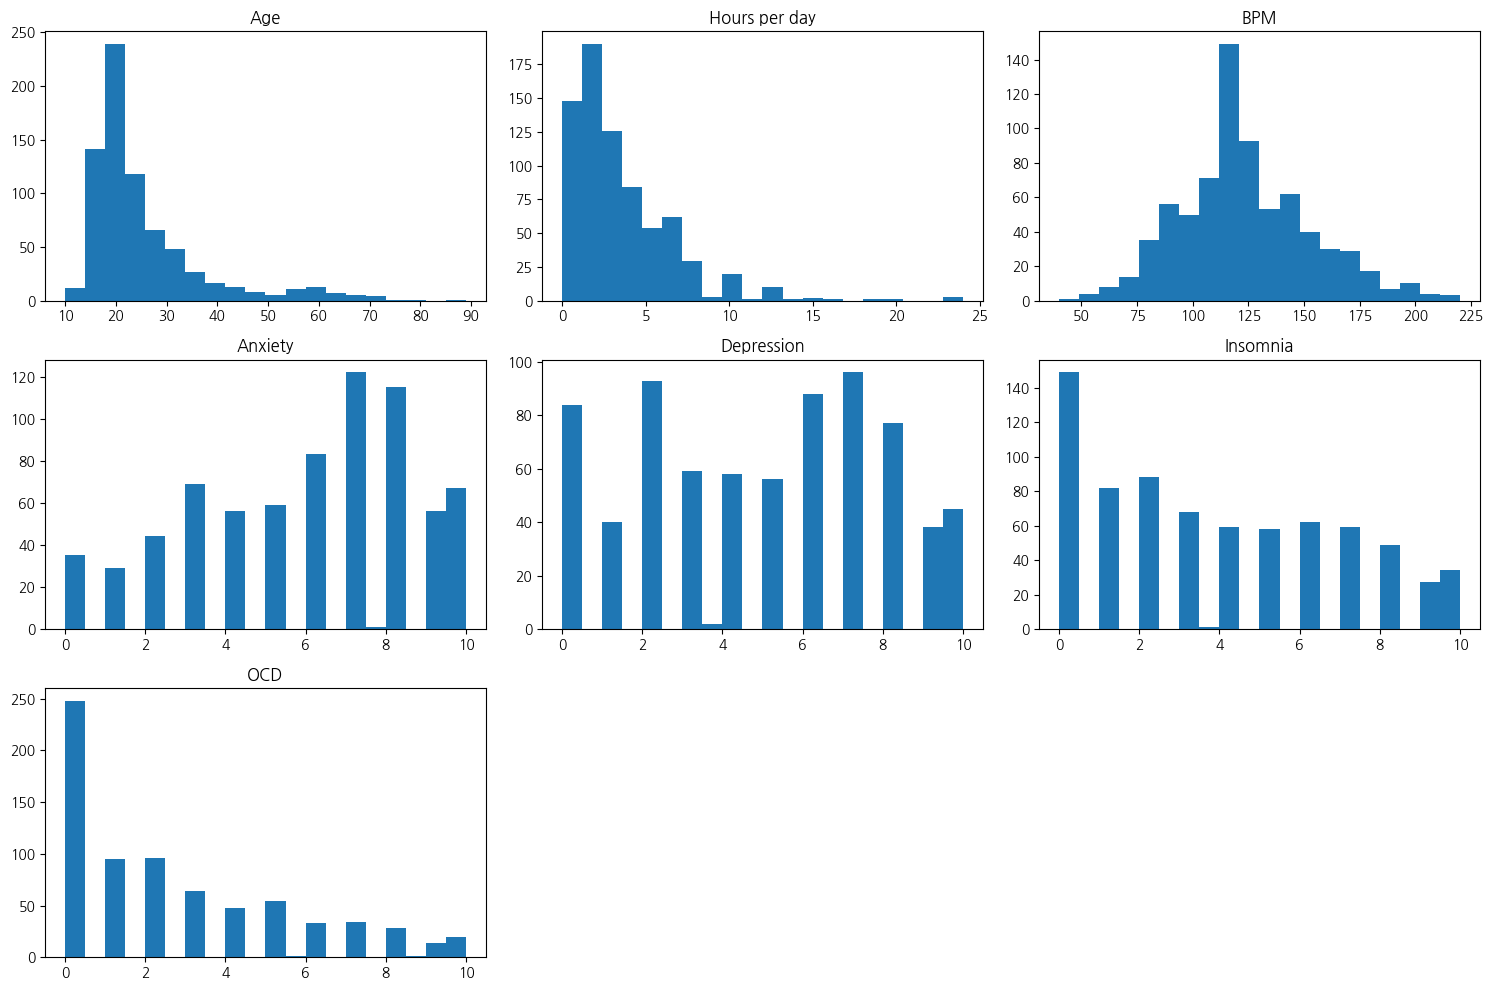

In [23]:
plot_outliers(df)

# 4. 의제: 하루에 음악을 많이 들을수록 정신 건강에 긍정적인가?

- 상관계수-EDA

- 정신건강 관련 지표 : Anxiety, Depression, Insomnia, OCD와 음악
- 청취시간 분포 : Hours per day

- 피어슨 상관계수 계산 및 시각화
- 스피어만 상관계수 계산 및 시각화

Pearson Correlation Matrix:
               Hours per day   Anxiety  Depression  Insomnia       OCD
Hours per day       1.000000  0.049319    0.110527  0.141821  0.118729
Anxiety             0.049319  1.000000    0.519969  0.292669  0.348350
Depression          0.110527  0.519969    1.000000  0.378996  0.196988
Insomnia            0.141821  0.292669    0.378996  1.000000  0.226354
OCD                 0.118729  0.348350    0.196988  0.226354  1.000000


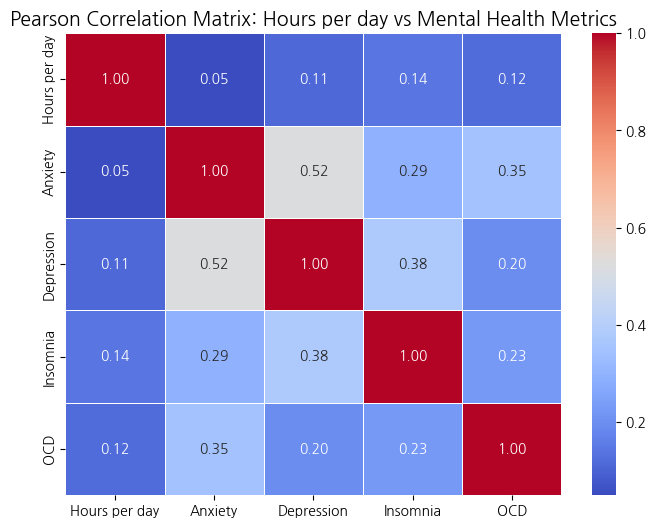


Spearman Correlation Matrix:
               Hours per day   Anxiety  Depression  Insomnia       OCD
Hours per day       1.000000  0.094299    0.135172  0.148057  0.125355
Anxiety             0.094299  1.000000    0.511688  0.293763  0.342883
Depression          0.135172  0.511688    1.000000  0.386264  0.208211
Insomnia            0.148057  0.293763    0.386264  1.000000  0.240659
OCD                 0.125355  0.342883    0.208211  0.240659  1.000000


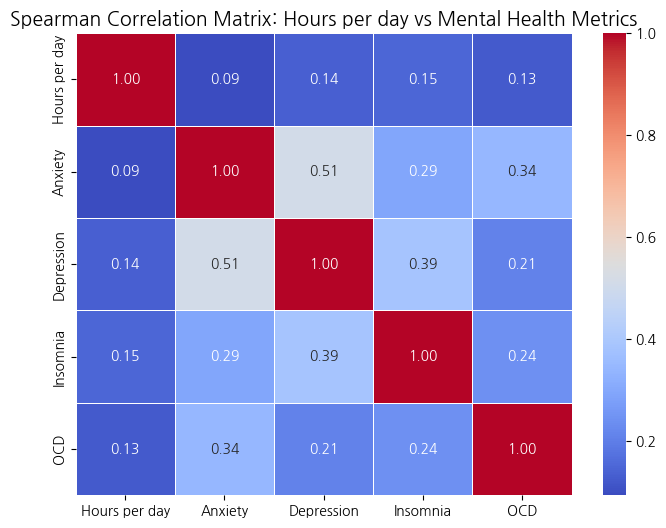

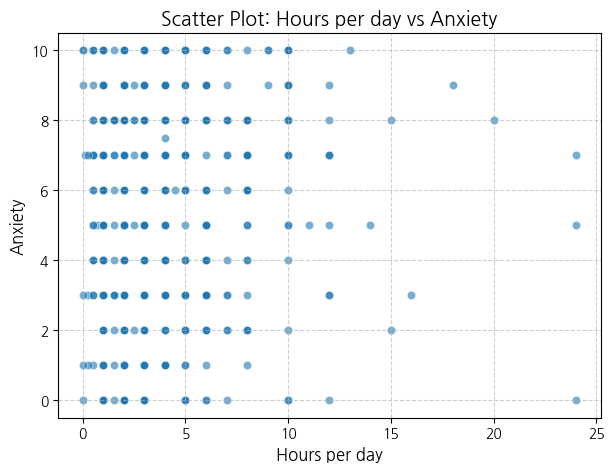

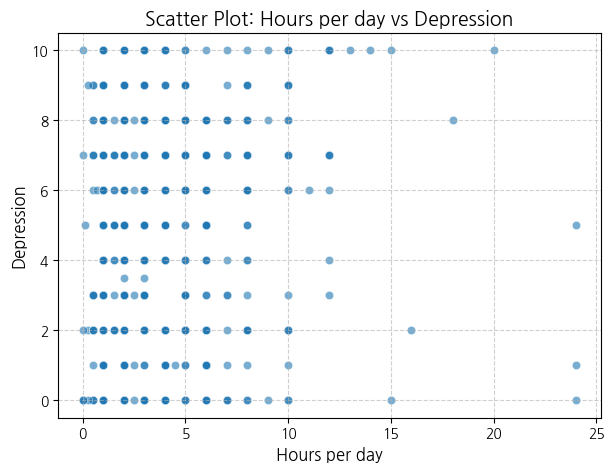

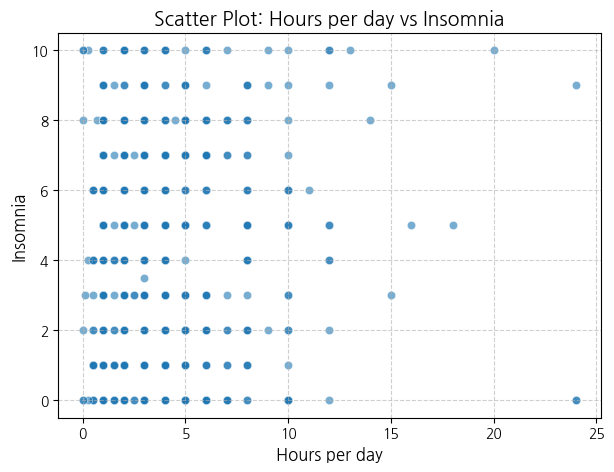

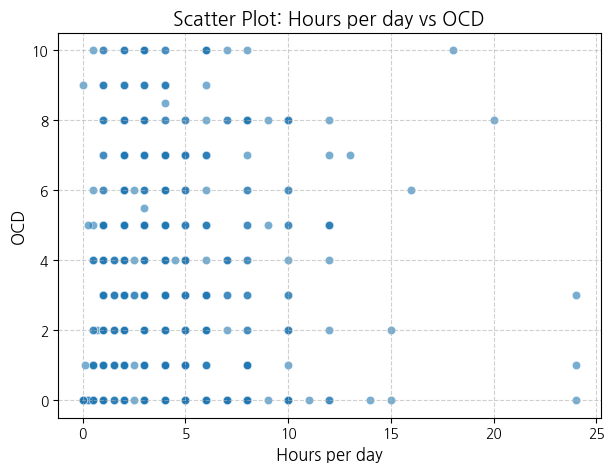

In [24]:
import matplotlib.pyplot as plt
# 4. 의제 분석: 하루 음악 청취 시간과 정신 건강 지표 간의 상관 관계

# 분석 대상 컬럼 선택
health_metrics = ['Anxiety', 'Depression', 'Insomnia', 'OCD']
correlation_cols = ['Hours per day'] + health_metrics

# 상관 분석을 위한 데이터프레임 선택
df_corr = df[correlation_cols]

# 1. 피어슨 상관계수 계산 및 시각화
pearson_corr = df_corr.corr(method='pearson')

print("Pearson Correlation Matrix:")
print(pearson_corr)

plt.figure(figsize=(8, 6))
sns.heatmap(pearson_corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Pearson Correlation Matrix: Hours per day vs Mental Health Metrics', fontsize=14)
plt.show()

# 2. 스피어만 상관계수 계산 및 시각화
spearman_corr = df_corr.corr(method='spearman')

print("\nSpearman Correlation Matrix:")
print(spearman_corr)

plt.figure(figsize=(8, 6))
sns.heatmap(spearman_corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Spearman Correlation Matrix: Hours per day vs Mental Health Metrics', fontsize=14)
plt.show()

# 3. 'Hours per day'와 각 정신 건강 지표 간의 산점도 시각화
for metric in health_metrics:
    plt.figure(figsize=(7, 5))
    sns.scatterplot(data=df_corr, x='Hours per day', y=metric, alpha=0.6)
    plt.title(f'Scatter Plot: Hours per day vs {metric}', fontsize=14)
    plt.xlabel('Hours per day', fontsize=12)
    plt.ylabel(metric, fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()


- 엘라스틱넷 회귀 모델을 사용해서 'Hours per day' 변수가 'Anxiety' 변수에 미치는 영향을 분석

In [25]:
from sklearn.linear_model import ElasticNet
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

X = df_corr[['Hours per day']]
y = df_corr['Anxiety']

# 결측치 제거
X = X.dropna()
y = y.loc[X.index].dropna()

if len(X) > 0 and len(y) > 0:
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    elastic_model = ElasticNet(alpha=1.0, l1_ratio=0.5, random_state=42)

    # 모델 학습
    elastic_model.fit(X_train, y_train)

    # 예측
    y_pred = elastic_model.predict(X_test)

    # 결과 평가
    print("\nElastic Net Regression Results for Anxiety:")
    print(f"Coefficient for Hours per day: {elastic_model.coef_[0]:.4f}")
    print(f"Intercept: {elastic_model.intercept_:.4f}")
    print(f"Mean Squared Error: {mean_squared_error(y_test, y_pred):.4f}")
    print(f"R-squared: {r2_score(y_test, y_pred):.4f}")
else:
    print("\nNot enough data points after dropping NaNs to perform Elastic Net regression.")


Elastic Net Regression Results for Anxiety:
Coefficient for Hours per day: 0.0000
Intercept: 5.8265
Mean Squared Error: 8.0786
R-squared: -0.0004


딱히 음악 시간과 정신건강 사이에 큰 상관관계가 없었음을 알 수 있었다 --> 이에 따라서 Music effects와 정신건강 사이의 관계 알아보기

음악이 자신의 정신 건강에 어떤 영향을 미친다고 느끼는지(Music effects: 'Improve', 'Worsen', 'No effect')에 따라서 실제 정신 건강 지표(Anxiety, Depression, Insomnia, OCD 점수)가 어떻게 분포하는 지 시각화

/tmp/ipython-input-26-1629004878.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


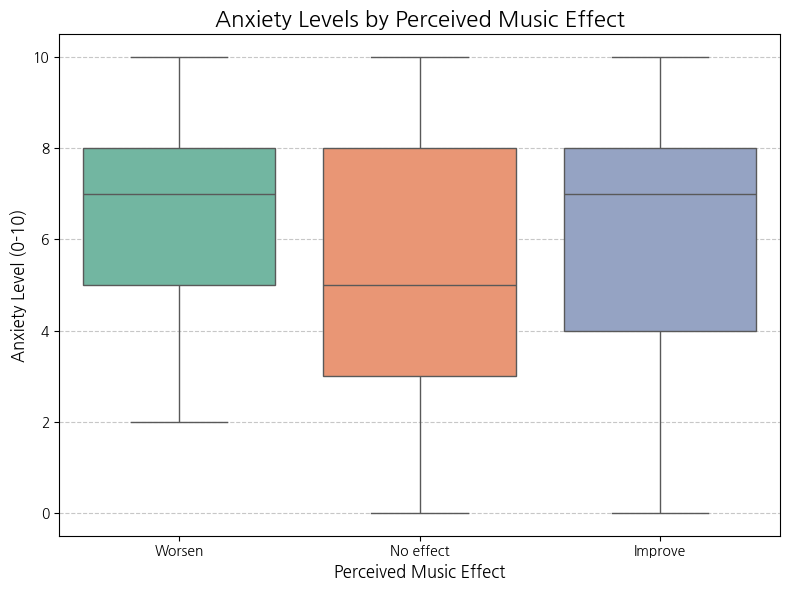

/tmp/ipython-input-26-1629004878.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Music effects', y=indicator, data=df, order=effect_order, palette='Set2')
/tmp/ipython-input-26-1629004878.py:28: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) NanumGothic.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) NanumGothic.
  fig.canvas.print_figure(bytes_io, **kw)


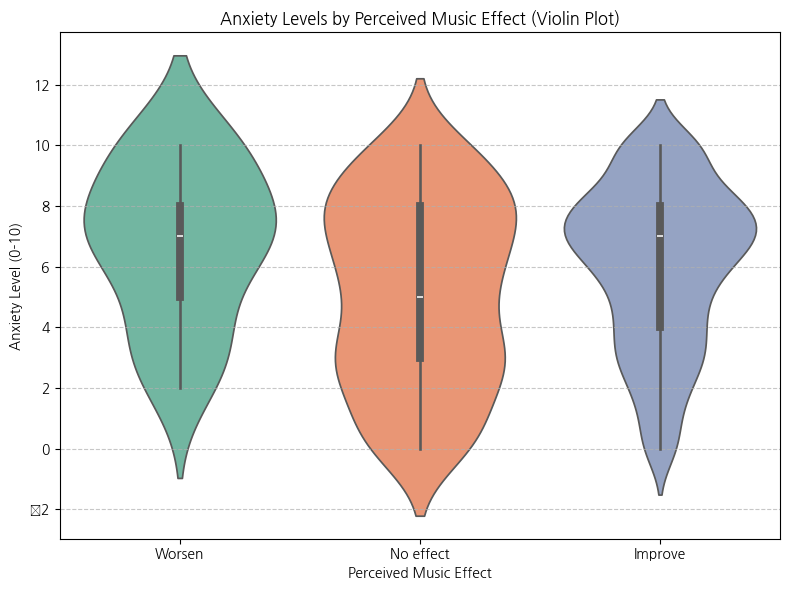

/tmp/ipython-input-26-1629004878.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


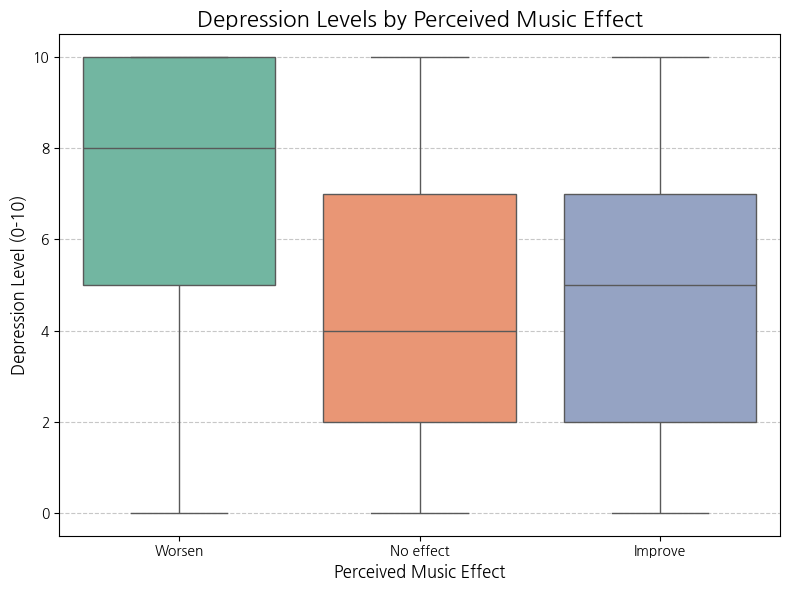

/tmp/ipython-input-26-1629004878.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Music effects', y=indicator, data=df, order=effect_order, palette='Set2')
/tmp/ipython-input-26-1629004878.py:28: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) NanumGothic.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) NanumGothic.
  fig.canvas.print_figure(bytes_io, **kw)


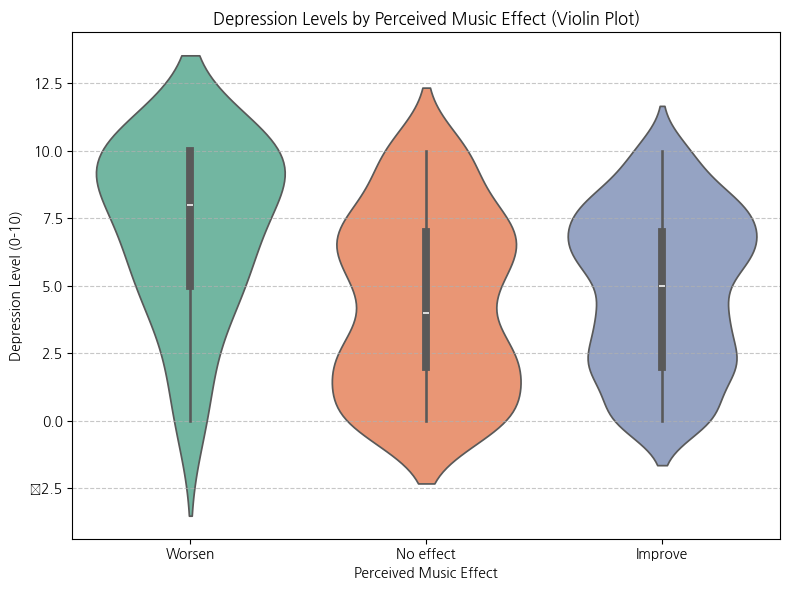

/tmp/ipython-input-26-1629004878.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


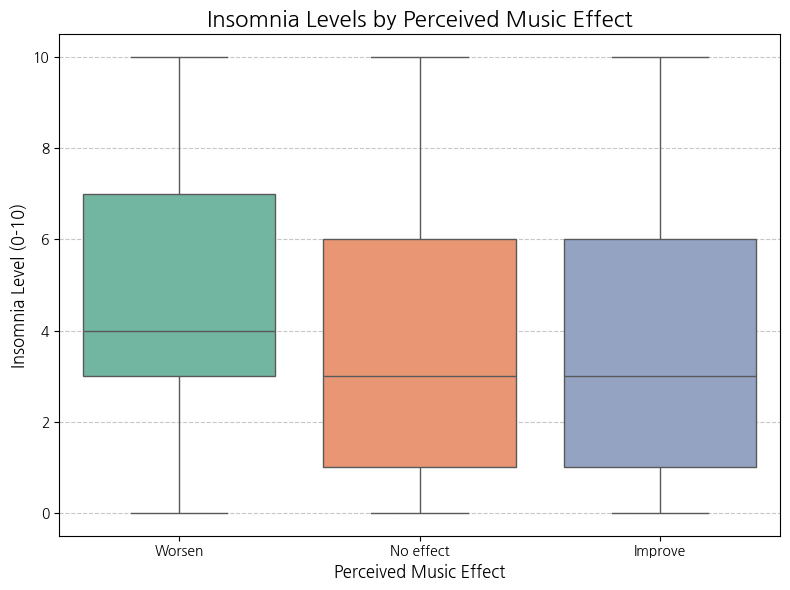

/tmp/ipython-input-26-1629004878.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Music effects', y=indicator, data=df, order=effect_order, palette='Set2')
/tmp/ipython-input-26-1629004878.py:28: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) NanumGothic.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) NanumGothic.
  fig.canvas.print_figure(bytes_io, **kw)


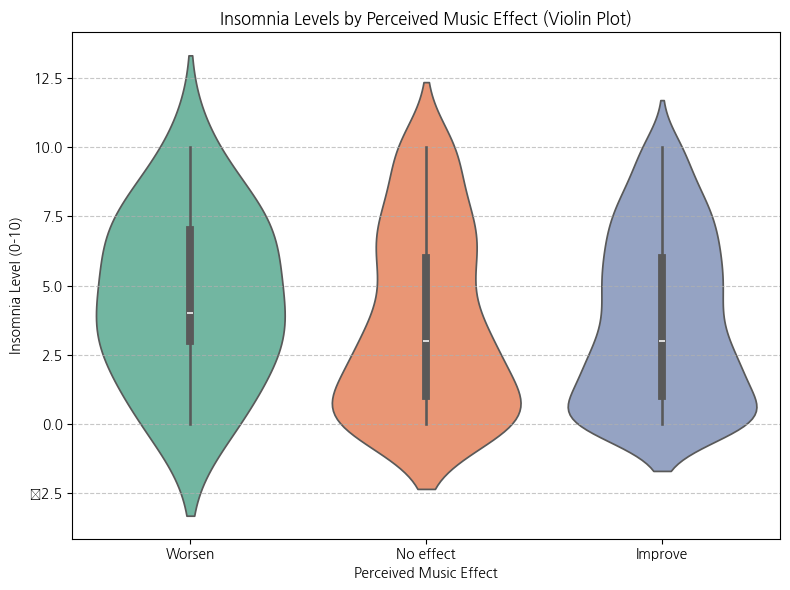

/tmp/ipython-input-26-1629004878.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


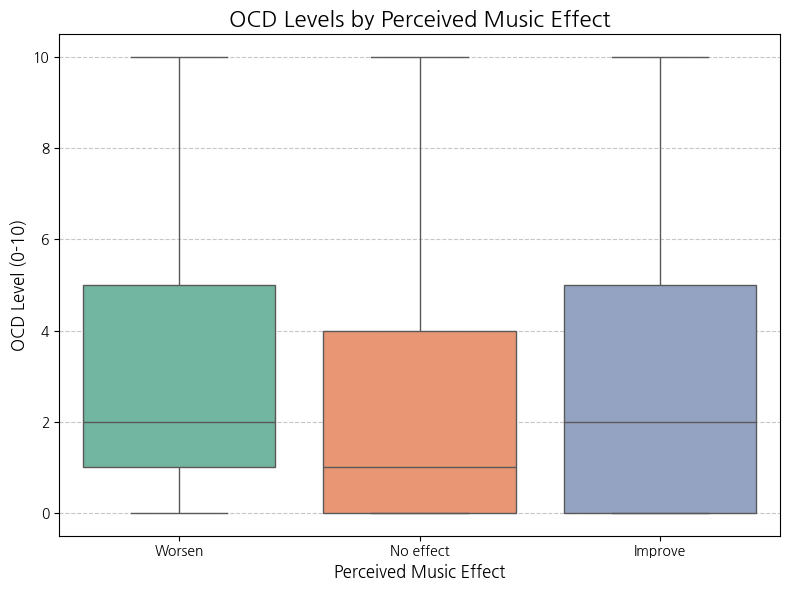

/tmp/ipython-input-26-1629004878.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Music effects', y=indicator, data=df, order=effect_order, palette='Set2')
/tmp/ipython-input-26-1629004878.py:28: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) NanumGothic.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) NanumGothic.
  fig.canvas.print_figure(bytes_io, **kw)


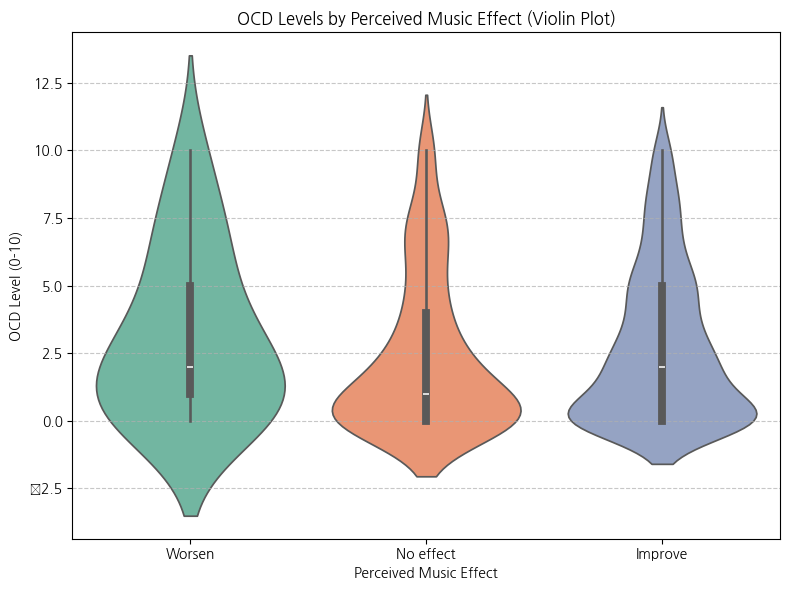

In [26]:
mental_health_indicators = ['Anxiety', 'Depression', 'Insomnia', 'OCD']
# Music effects의 범주 순서를 지정하여 시각화의 논리적 흐름 유지
effect_order = ['Worsen', 'No effect', 'Improve'] # 악화 -> 효과 없음 -> 개선 순으로 정렬하면 비교가 더 명확할 수 있습니다.

for indicator in mental_health_indicators:
    plt.figure(figsize=(8, 6))
    sns.boxplot(
        x='Music effects',
        y=indicator,
        data=df,
        order=effect_order,
        palette='Set2' # 다른 색상 팔레트 사용
    )
    plt.title(f'{indicator} Levels by Perceived Music Effect', fontsize=16)
    plt.xlabel('Perceived Music Effect', fontsize=12)
    plt.ylabel(f'{indicator} Level (0-10)', fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

    # 바이올렛 플롯
    plt.figure(figsize=(8, 6))
    sns.violinplot(x='Music effects', y=indicator, data=df, order=effect_order, palette='Set2')
    plt.title(f'{indicator} Levels by Perceived Music Effect (Violin Plot)')
    plt.xlabel('Perceived Music Effect')
    plt.ylabel(f'{indicator} Level (0-10)')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

음악이 정신 건강에 미치는 영향에 대한 주관적인 인식(Music effects 컬럼)에 따라 사람들이 어떤 음악 청취 습관(Hours per day, Fav genre, Primary streaming service, While working)을 보이는지를 시각화

In [27]:
# Music effects 그룹별 Hours per day 박스 플롯/바이올린 플롯

/tmp/ipython-input-28-648672701.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Music effects', y='Hours per day', data=df, order=effect_order, palette='viridis')


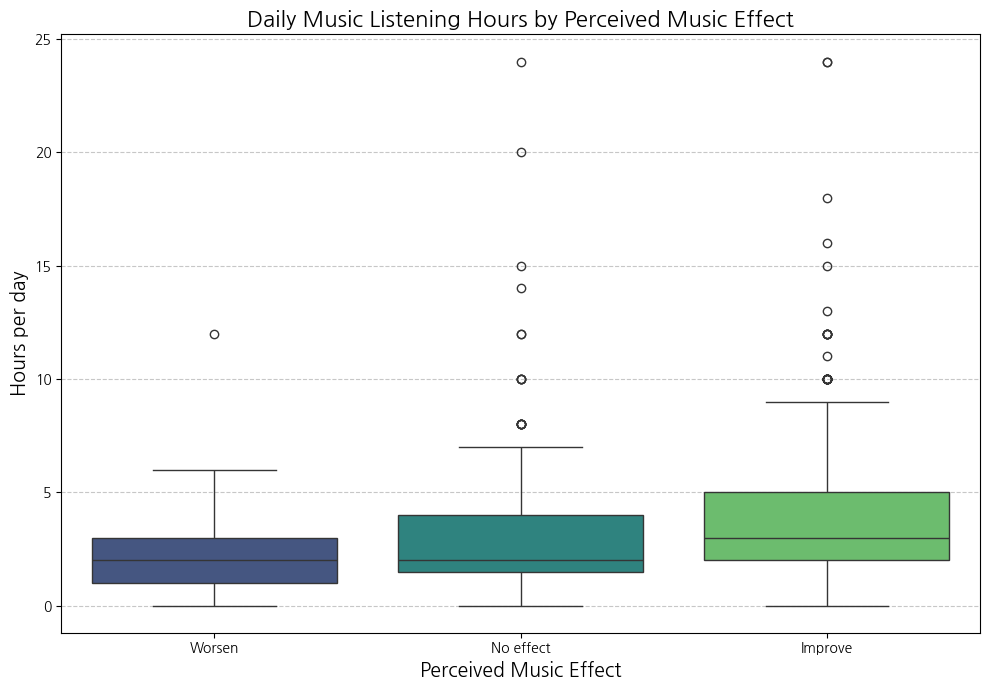

/tmp/ipython-input-28-648672701.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Music effects', y='Hours per day', data=df, order=effect_order, palette='viridis')


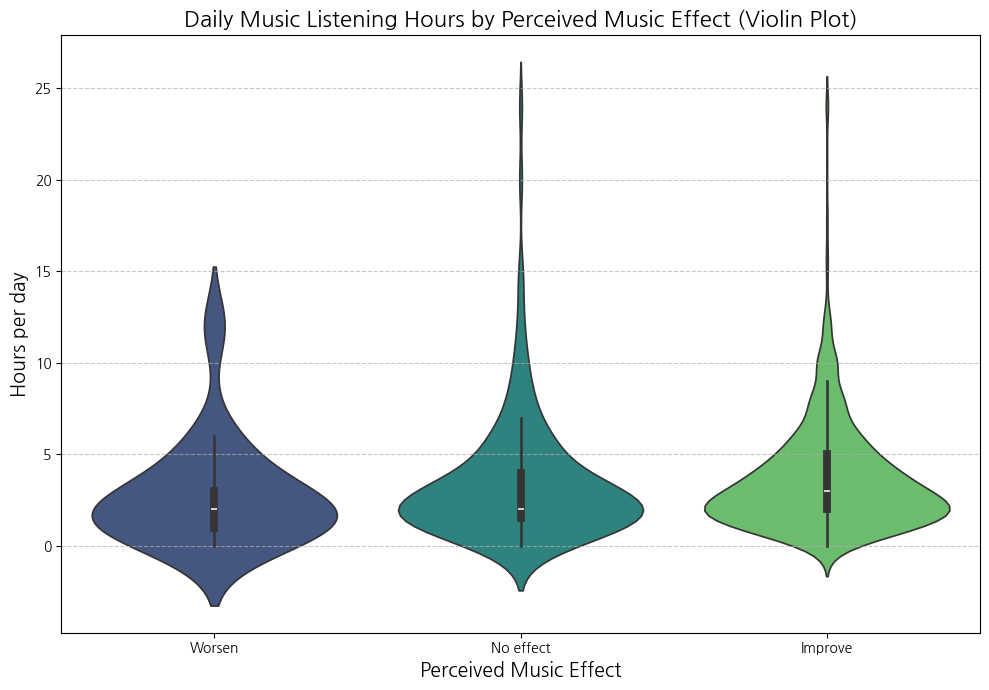

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Music effects의 범주 순서를 지정하여 시각화의 논리적 흐름 유지
effect_order = ['Worsen', 'No effect', 'Improve']

plt.figure(figsize=(10, 7))
sns.boxplot(x='Music effects', y='Hours per day', data=df, order=effect_order, palette='viridis')
plt.title('Daily Music Listening Hours by Perceived Music Effect', fontsize=16)
plt.xlabel('Perceived Music Effect', fontsize=14)
plt.ylabel('Hours per day', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# 바이올린 플롯도 함께 보면 분포의 밀도를 더 잘 알 수 있습니다.
plt.figure(figsize=(10, 7))
sns.violinplot(x='Music effects', y='Hours per day', data=df, order=effect_order, palette='viridis')
plt.title('Daily Music Listening Hours by Perceived Music Effect (Violin Plot)', fontsize=16)
plt.xlabel('Perceived Music Effect', fontsize=14)
plt.ylabel('Hours per day', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [29]:
# Worsen을 선택한 사람들에 비해 improve 사람들이 음악 시간을 더 많이 듣는 것 같음.

음악 효과에 대한 인식에 따라 선호하는 장르, 주요 스트리밍 서비스, 작업 중 음악 청취 여부의 분포가 어떻게 달라지는지 비교 시각화

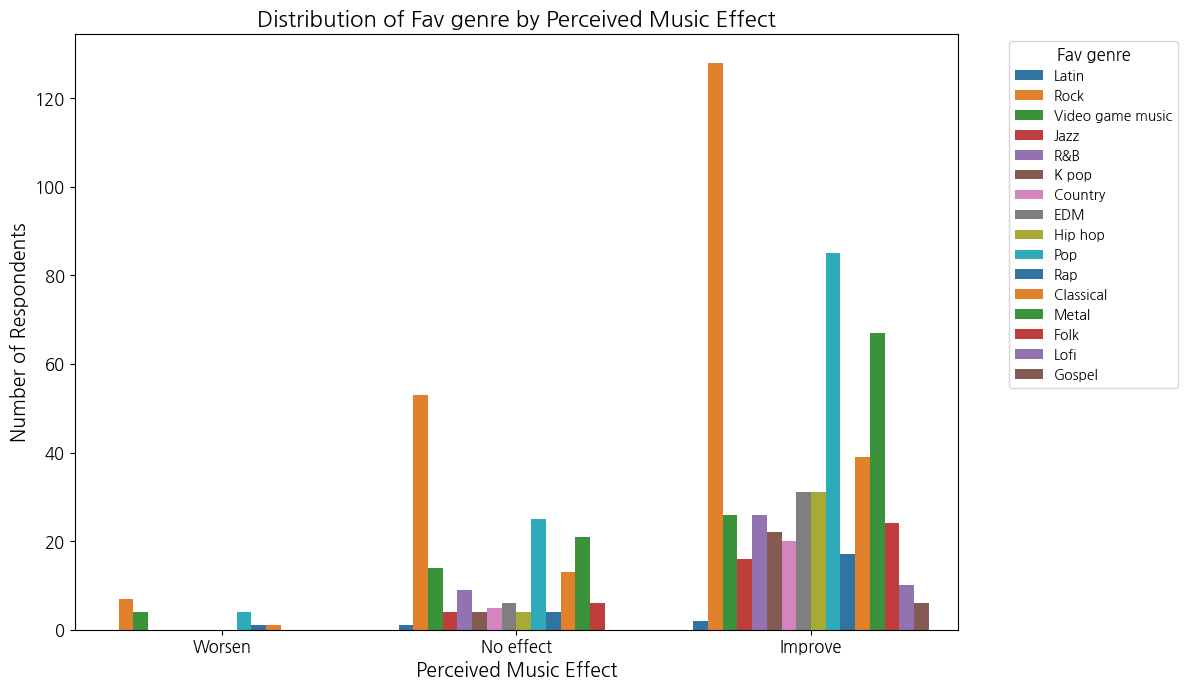

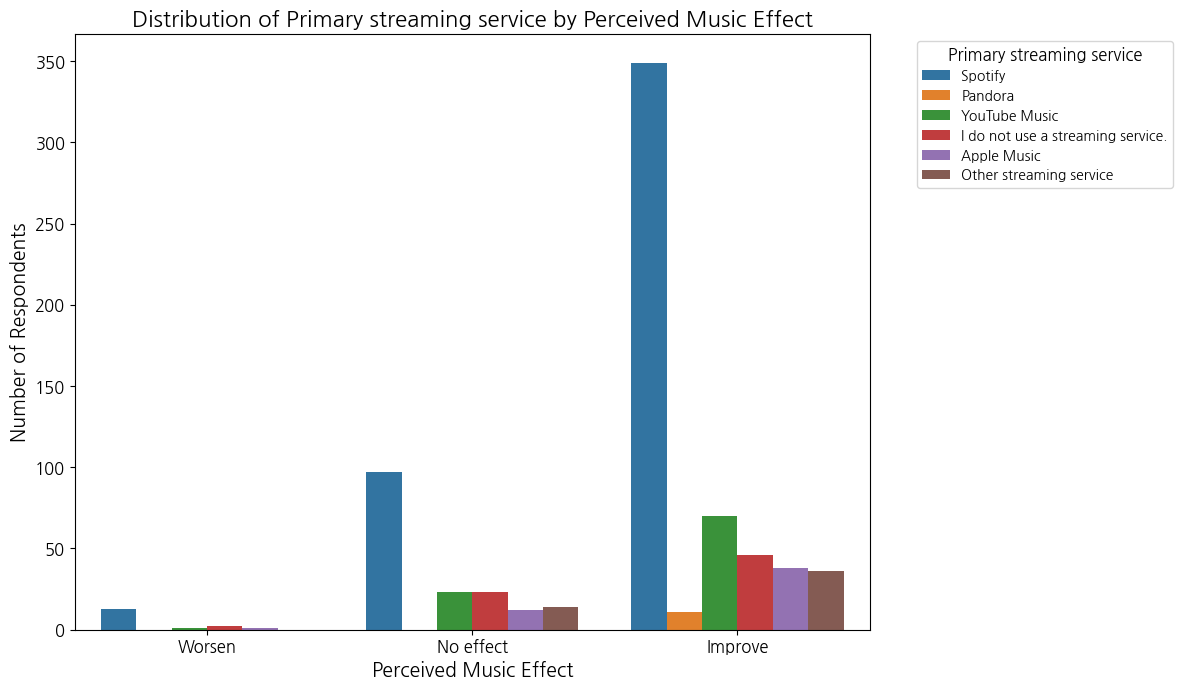

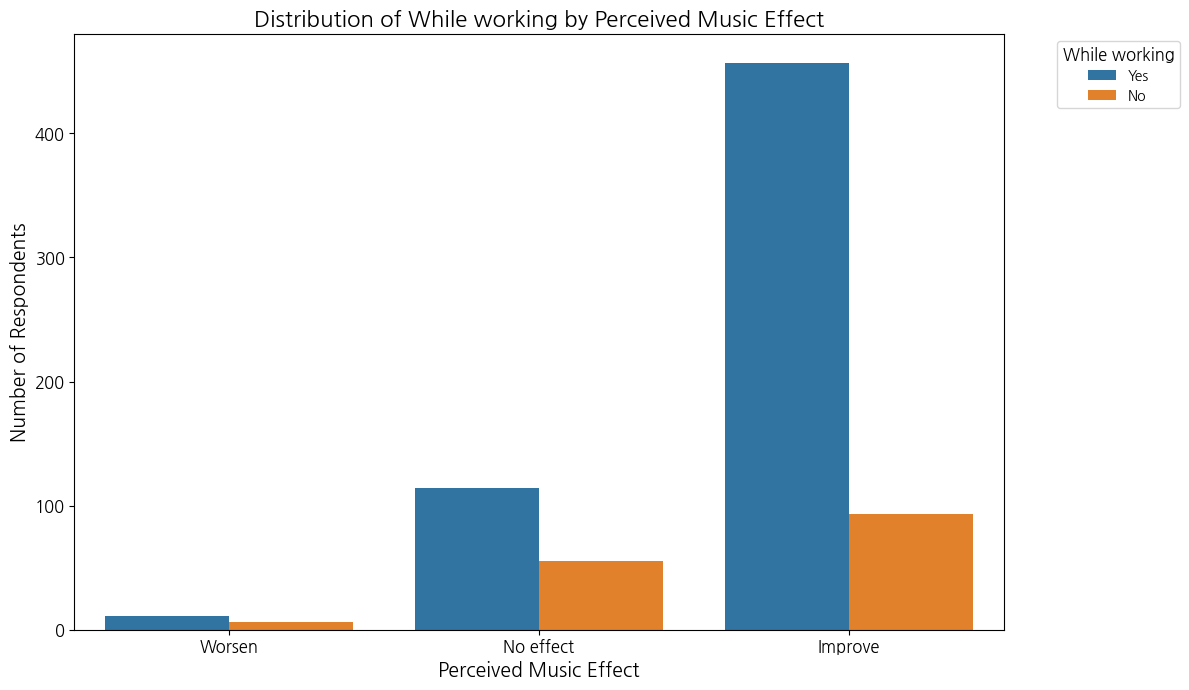

In [30]:

# 시각화할 범주형 컬럼 리스트
categorical_patterns = ['Fav genre', 'Primary streaming service', 'While working']

for col in categorical_patterns:
    plt.figure(figsize=(12, 7))
    # 각 음악 효과 그룹별로 해당 컬럼의 분포를 보여줍니다.
    sns.countplot(data=df, x='Music effects', hue=col, order=effect_order, palette='tab10')
    plt.title(f'Distribution of {col} by Perceived Music Effect', fontsize=16)
    plt.xlabel('Perceived Music Effect', fontsize=14)
    plt.ylabel('Number of Respondents', fontsize=14)
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    plt.legend(title=col, bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10, title_fontsize=12)
    plt.tight_layout()
    plt.show()

시각화해보니 imporve와 no effect에 비해서 worsen이 상대적으로 적다.
worsen 그룹의 정신 건강 지표 확인

In [31]:
import pandas as pd

# 'Music effects'가 'Worsen'인 응답자들만 필터링
worsen_group = df[df['Music effects'] == 'Worsen']

# 정신 건강 관련 변수들
mental_health_indicators = ['Anxiety', 'Depression', 'Insomnia', 'OCD']

print("--- Statistical Summary for 'Worsen' Group ---")
for indicator in mental_health_indicators:
    print(f"\n{indicator}:")
    # describe() 함수로 주요 통계량 확인
    print(worsen_group[indicator].describe())
    # 추가로 각 지표의 중앙값(median)도 확인
    print(f"Median {indicator}: {worsen_group[indicator].median():.2f}")
    # 그리고 전체 데이터에서의 해당 지표 평균/중앙값과 비교해볼 수 있습니다.
    print(f"Overall Median {indicator}: {df[indicator].median():.2f}")

--- Statistical Summary for 'Worsen' Group ---

Anxiety:
count    17.000000
mean      6.764706
std       2.610781
min       2.000000
25%       5.000000
50%       7.000000
75%       8.000000
max      10.000000
Name: Anxiety, dtype: float64
Median Anxiety: 7.00
Overall Median Anxiety: 6.00

Depression:
count    17.000000
mean      7.176471
std       3.107155
min       0.000000
25%       5.000000
50%       8.000000
75%      10.000000
max      10.000000
Name: Depression, dtype: float64
Median Depression: 8.00
Overall Median Depression: 5.00

Insomnia:
count    17.000000
mean      4.529412
std       2.939338
min       0.000000
25%       3.000000
50%       4.000000
75%       7.000000
max      10.000000
Name: Insomnia, dtype: float64
Median Insomnia: 4.00
Overall Median Insomnia: 3.00

OCD:
count    17.000000
mean      3.117647
std       3.100047
min       0.000000
25%       1.000000
50%       2.000000
75%       5.000000
max      10.000000
Name: OCD, dtype: float64
Median OCD: 2.00
Overall Me

(1) Anxiety
- 평균불안점수 : 6.72
- 중앙값 : 7.00
- 전체 데이터 중앙값 : 6.00
--> 평균적으로 더 높은 수준의 불안

(2) Depression
- 평균우울점수 : 7,18
- 중앙값 : 8.00
- 전체 데이터 중앙값 : 5.00
--> 전반적으로 매우 높은 우울 수준

(3) Insomnia
- 평균불면증점수 : 4.53
- 중앙값 : 4.00
- 전체 데이터 중앙값 : 3.00
--> 평균적으로 더 높은 불면증 증상

(4) OCD
- 평균강박증점수 : 3.12
- 중앙값 : 2.00
- 전체 데이터 중앙값 : 2.00
--> 별로 뚜렷한 차이를 보이지 않음

종합적으로 Worsen 그룹은 정신 건강에 취약한 경향이 있다.

음악의 주관적 효과 인식과 실제 정신 건강 상태 간의 강한 연관성을 띈다.

양적 접근의 한계 : Hours per day와 정신 건강 지표 간의 낮은 상관관계를 보았고, 이를 단순 얼마나 듣는가 보단 얼마나 느끼는가 라는 질적인 측명이 정신 건강에 더 큰 영향을 미침.

1. Music effects 그룹별 Age_Group 분포 비교 (막대 차트/countplot)

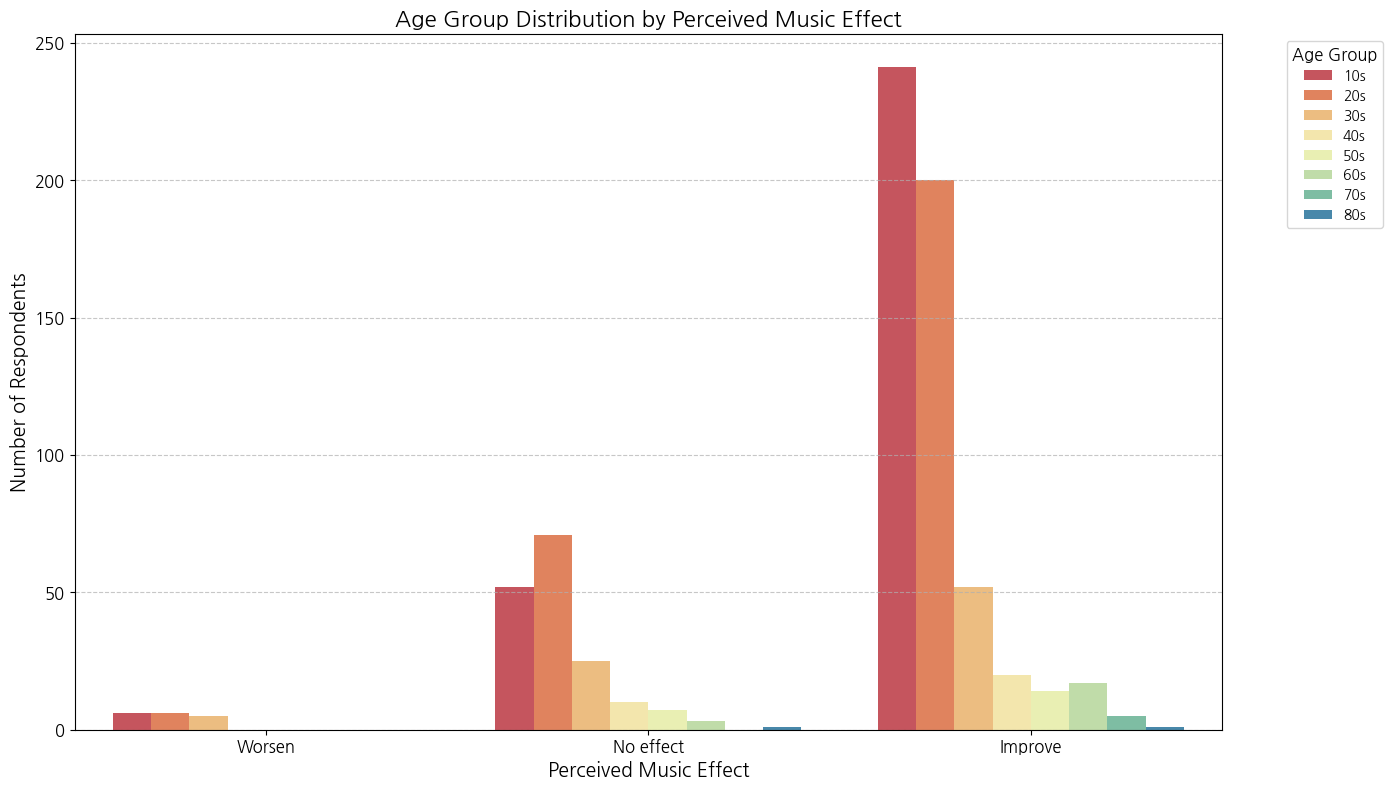

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Music effects의 범주 순서 지정
effect_order = ['Worsen', 'No effect', 'Improve']
age_group_order = ['10s', '20s', '30s', '40s', '50s', '60s', '70s', '80s', '90s', 'Unknown']


plt.figure(figsize=(14, 8))
sns.countplot(
    data=df,
    x='Music effects',
    hue='Age_Group',
    order=effect_order,
    hue_order=[ag for ag in age_group_order if ag in df['Age_Group'].unique()],
    palette='Spectral'
)
plt.title('Age Group Distribution by Perceived Music Effect', fontsize=16)
plt.xlabel('Perceived Music Effect', fontsize=14)
plt.ylabel('Number of Respondents', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(title='Age Group', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10, title_fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

2. Music effects 그룹별 Instrumentalist 및 Composer 여부 (막대 차트/countplot)


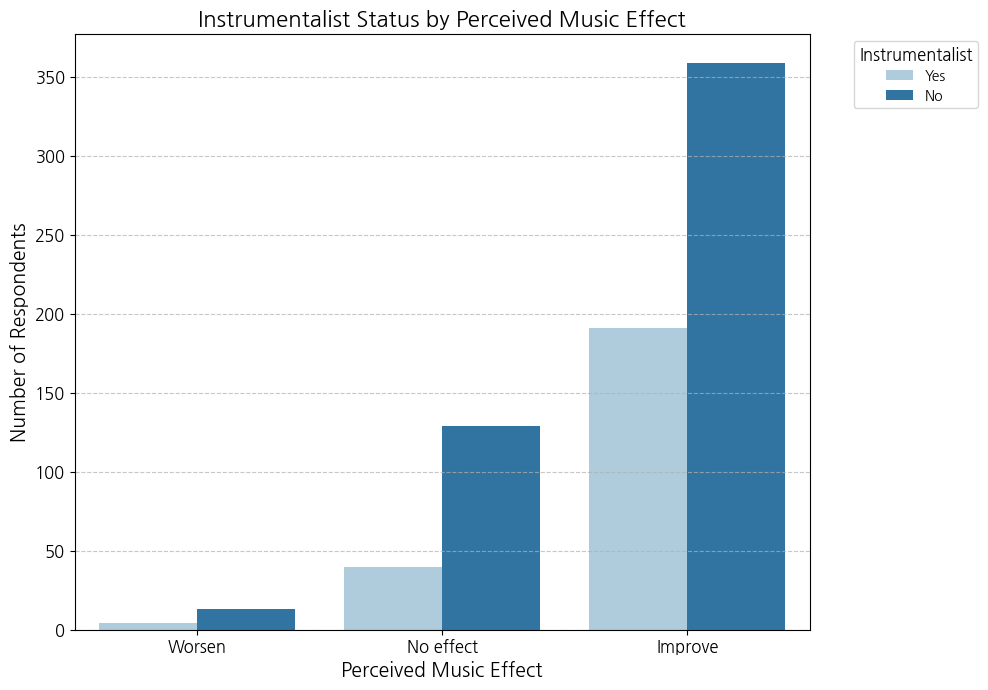

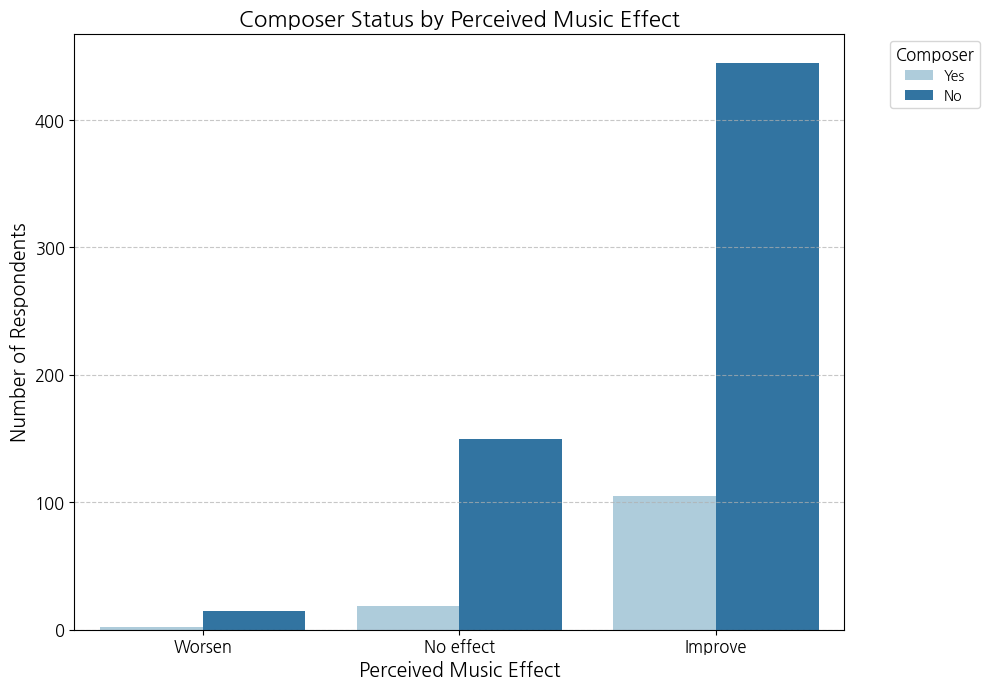

In [33]:
# 시각화할 음악적 배경 관련 범주형 컬럼 리스트
musical_background_cols = ['Instrumentalist', 'Composer']

for col in musical_background_cols:
    plt.figure(figsize=(10, 7))
    sns.countplot(
        data=df,
        x='Music effects',
        hue=col,
        order=effect_order,
        palette='Paired' # A good palette for binary categories (Yes/No)
    )
    plt.title(f'{col} Status by Perceived Music Effect', fontsize=16)
    plt.xlabel('Perceived Music Effect', fontsize=14)
    plt.ylabel('Number of Respondents', fontsize=14)
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    plt.legend(title=col, bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10, title_fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

Music effects 그룹별 특정 장르 선호도 및 청취 빈도 분석

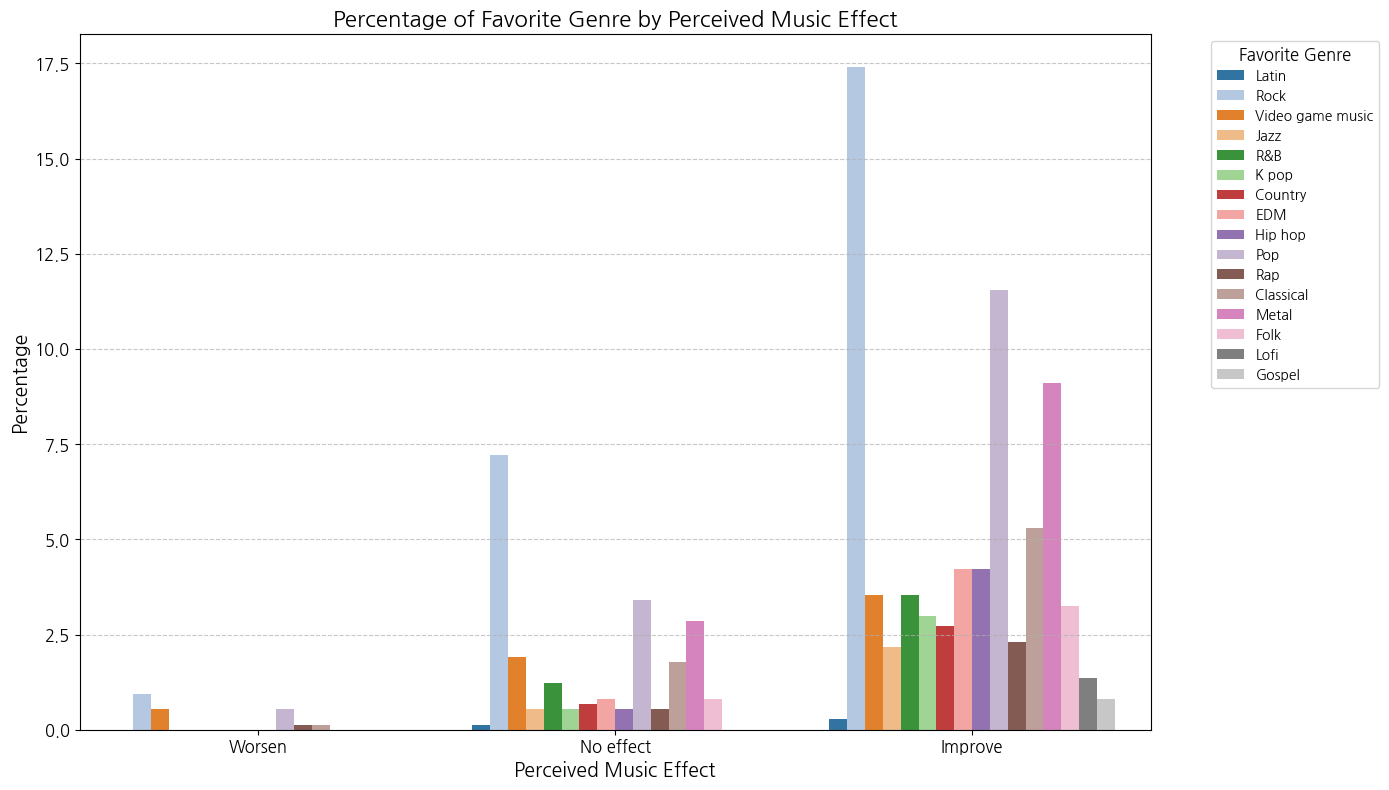

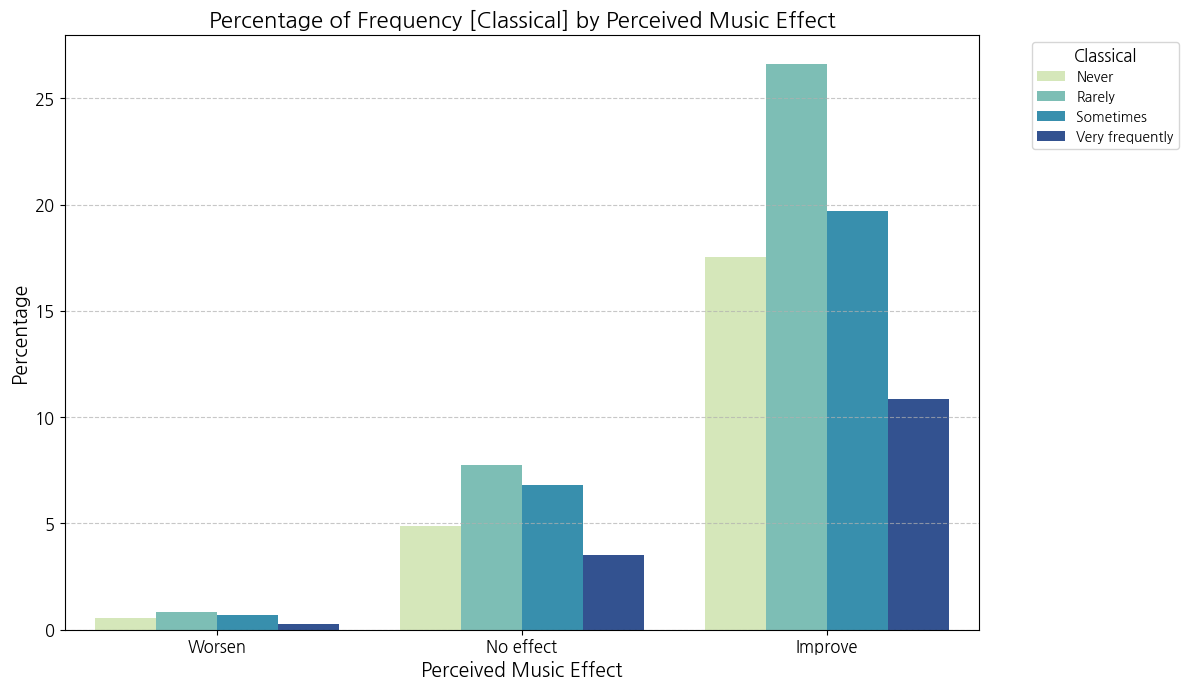

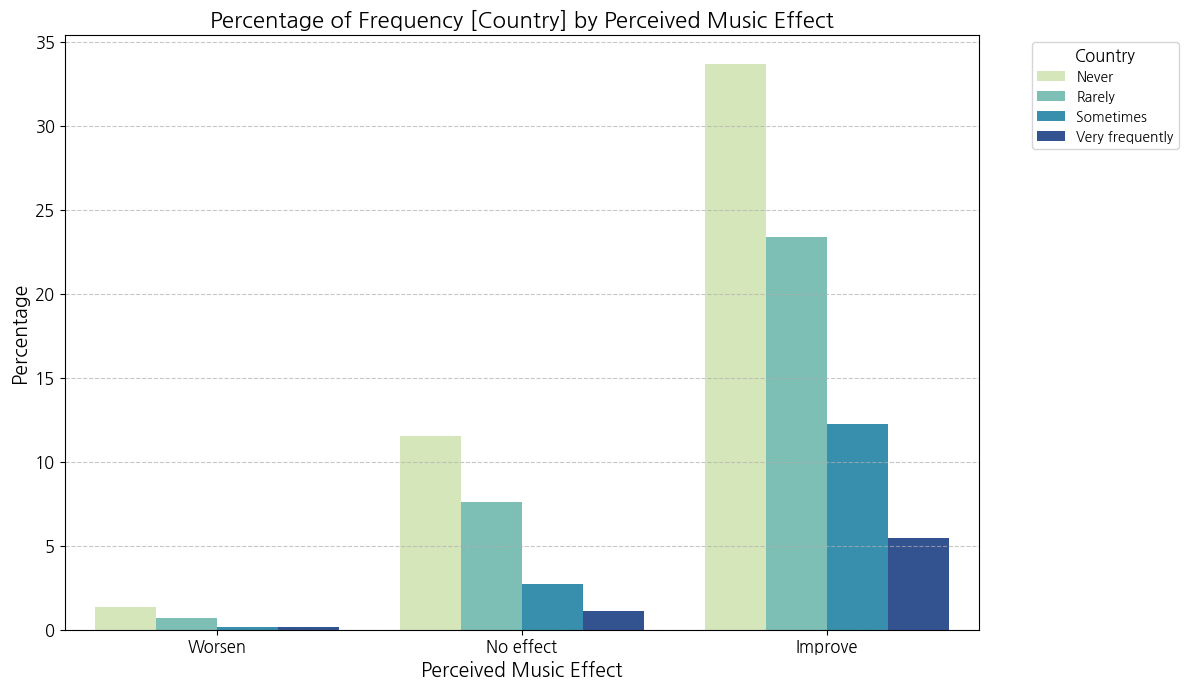

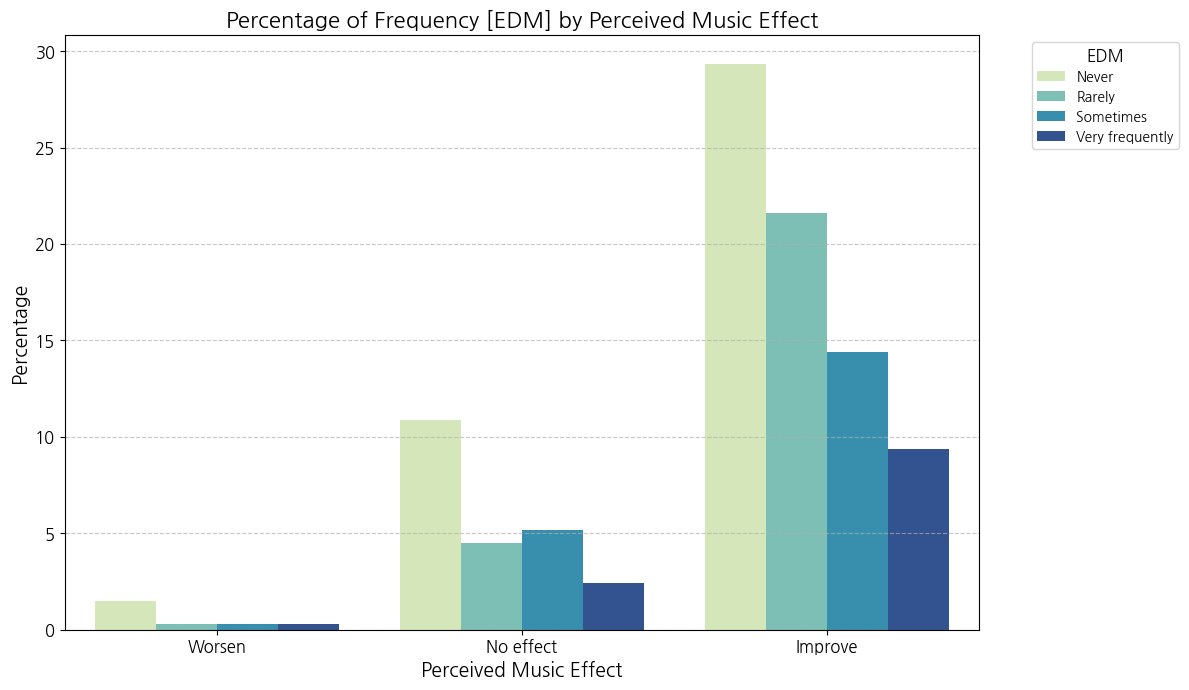

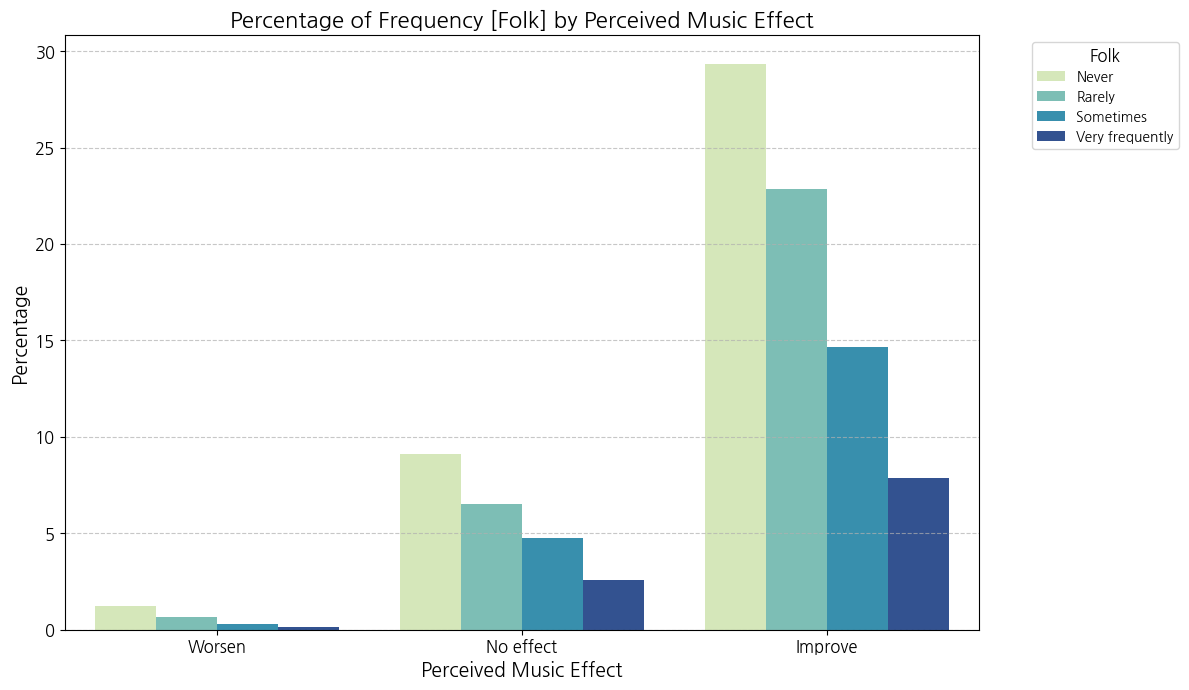

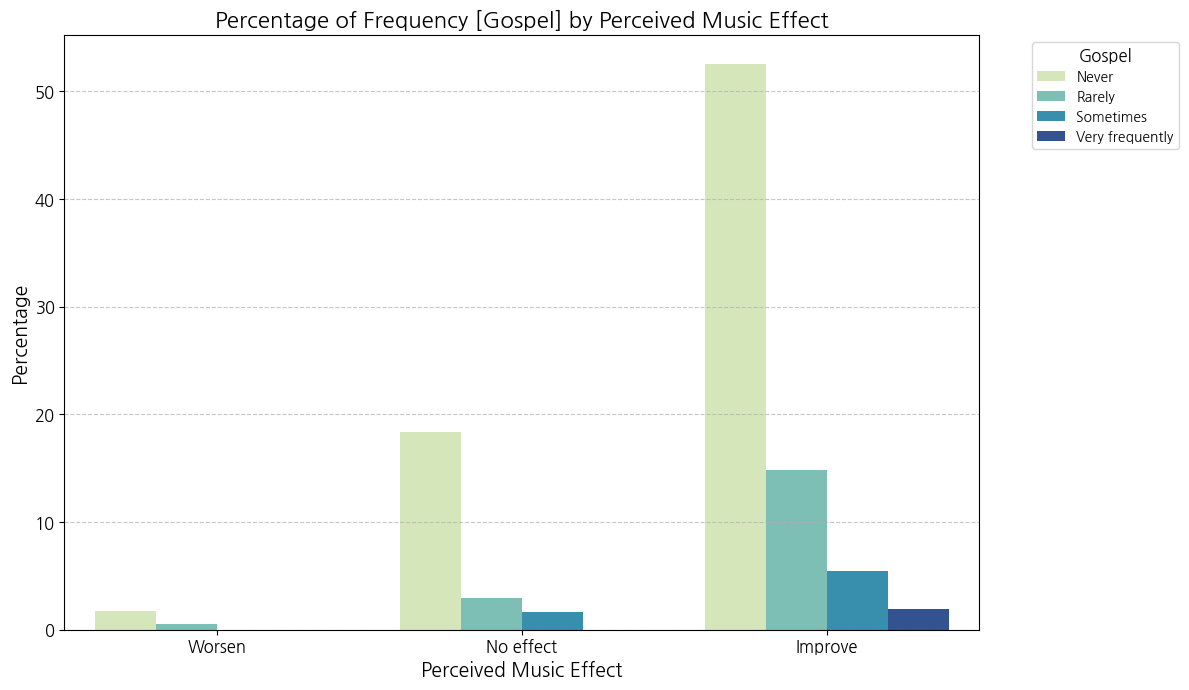

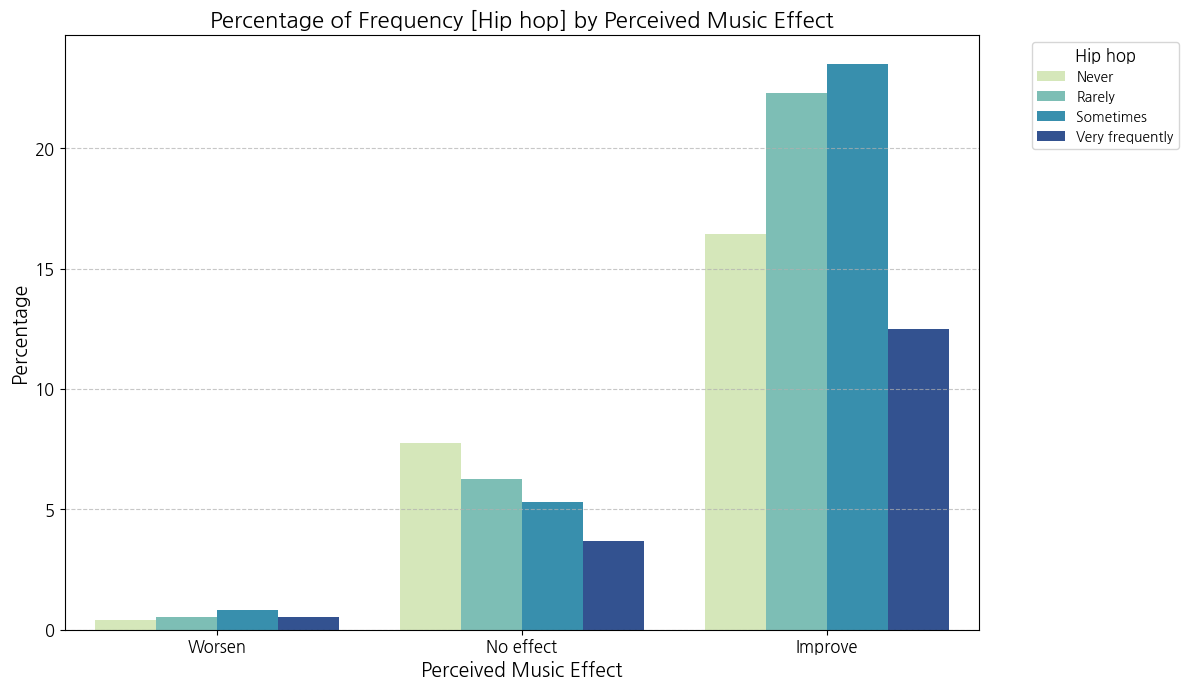

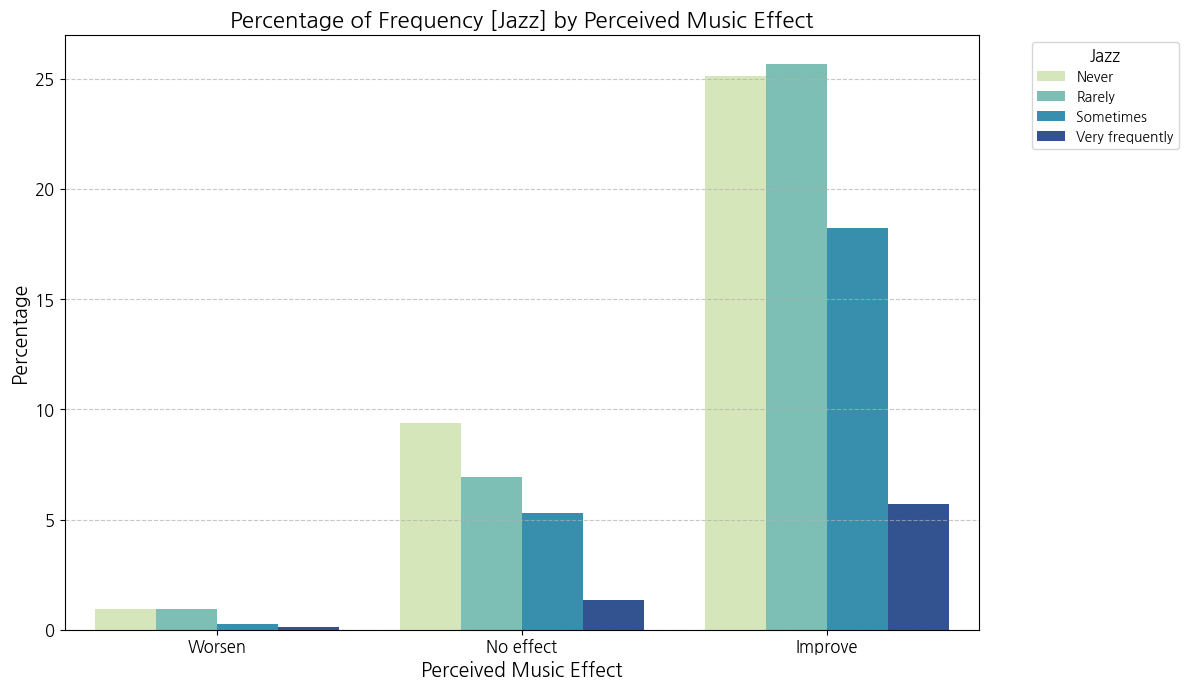

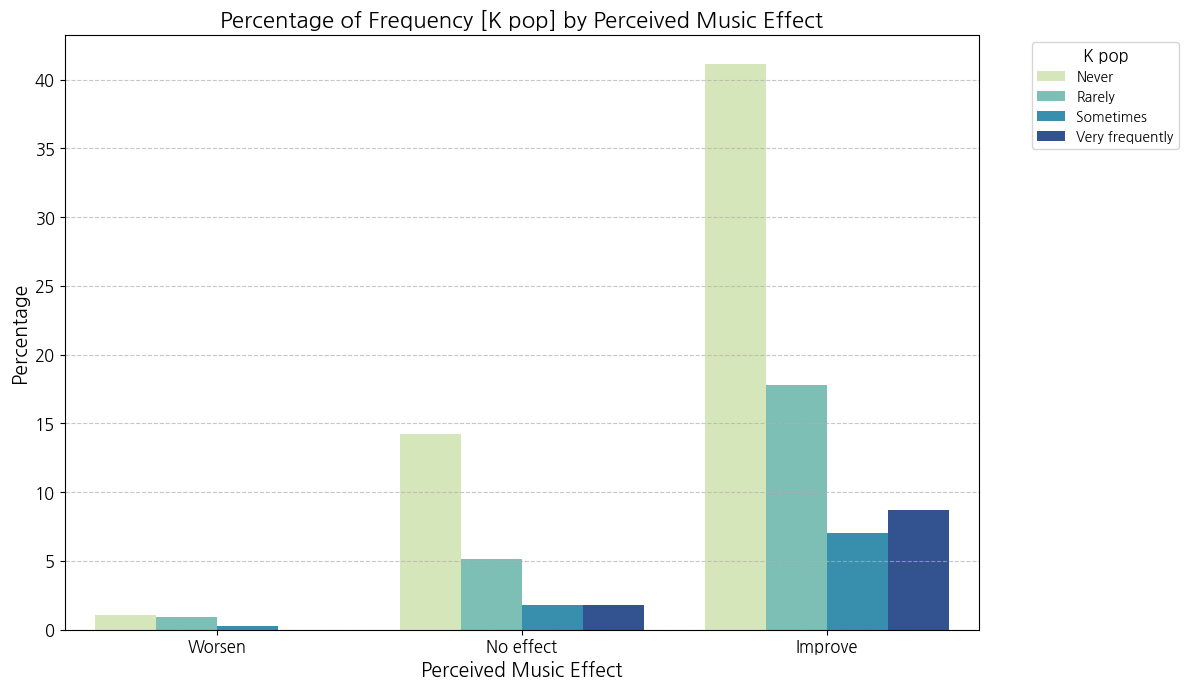

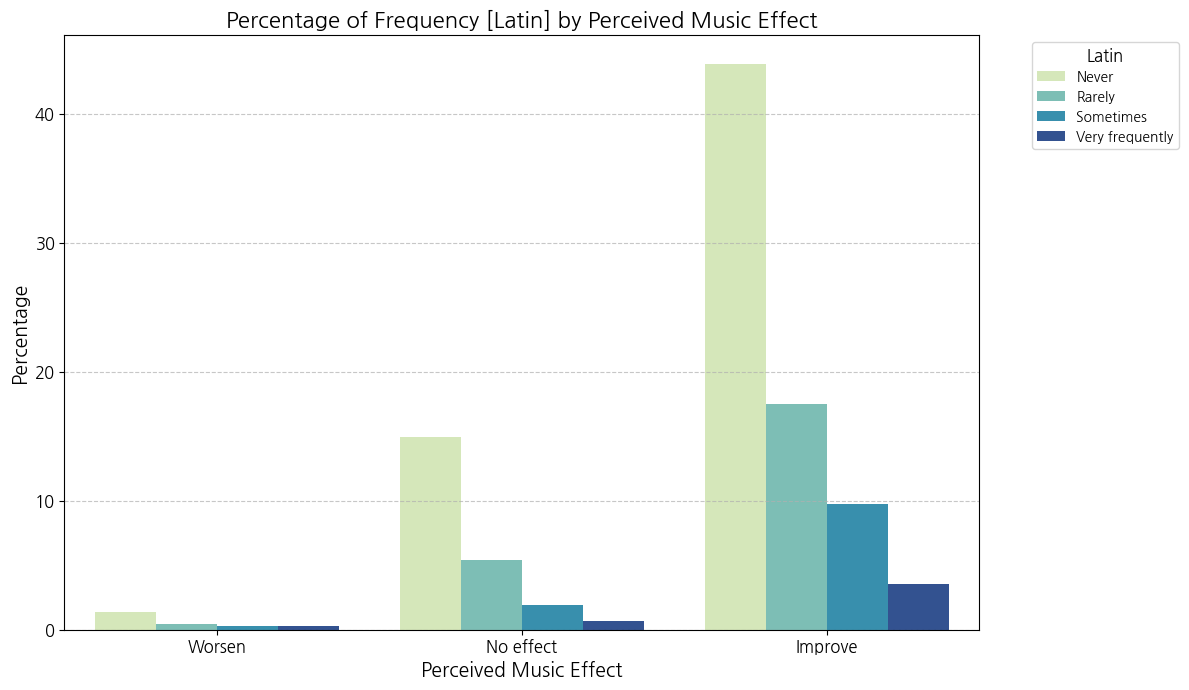

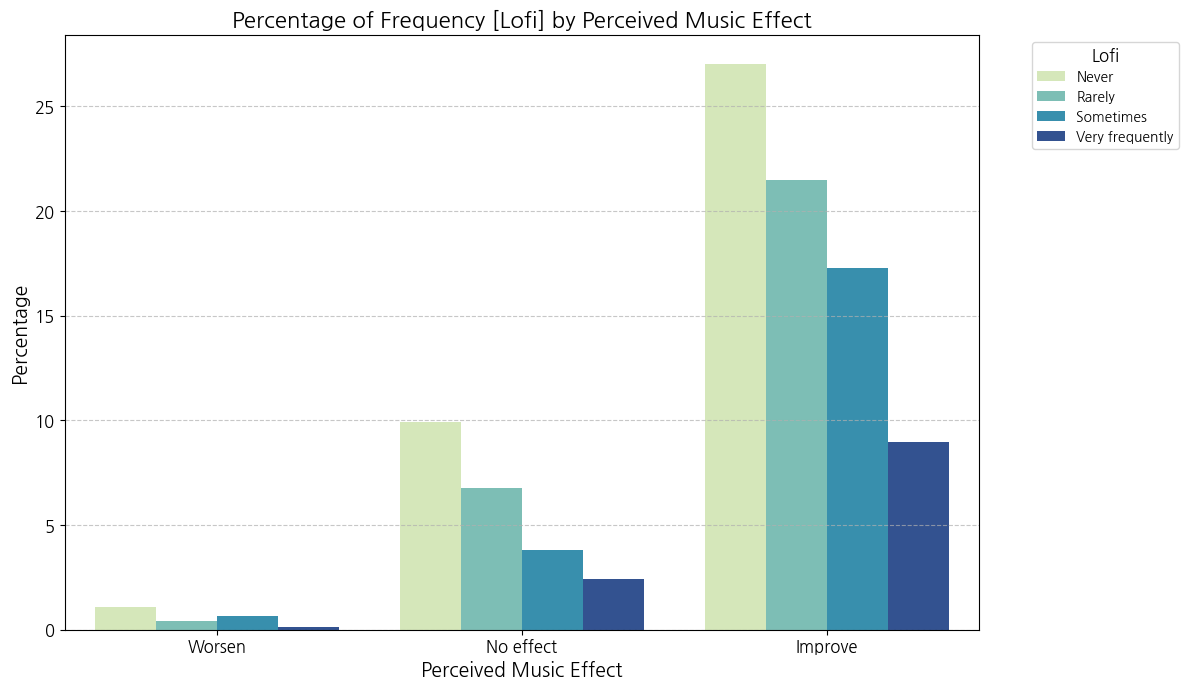

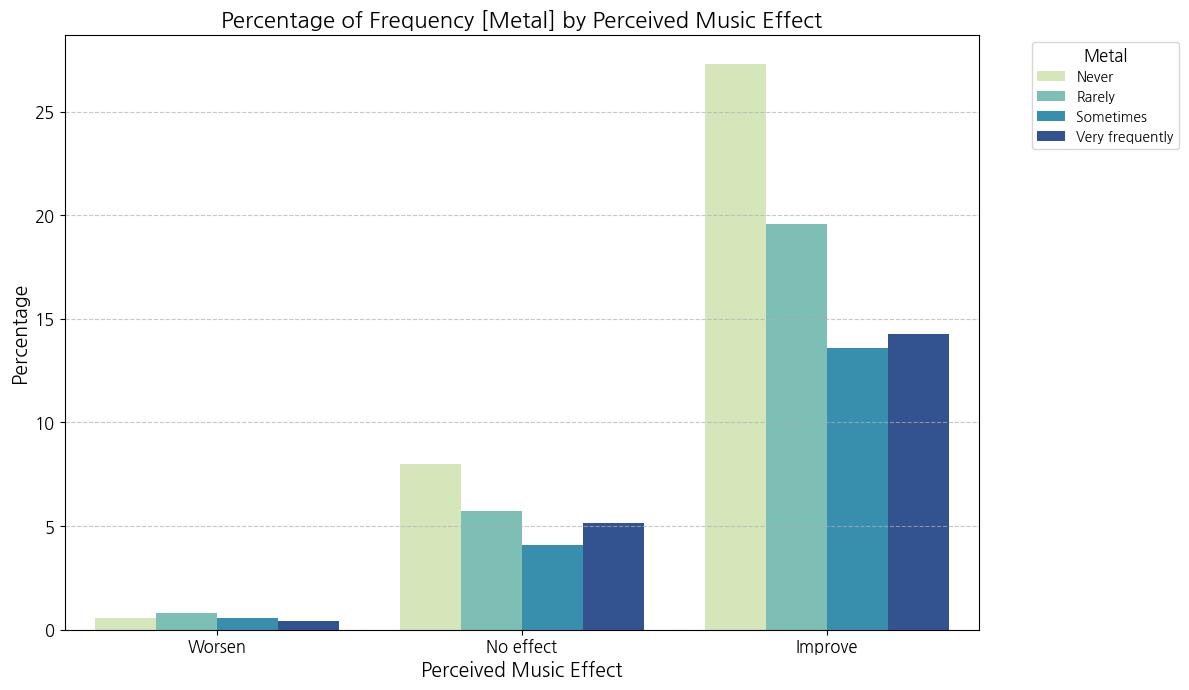

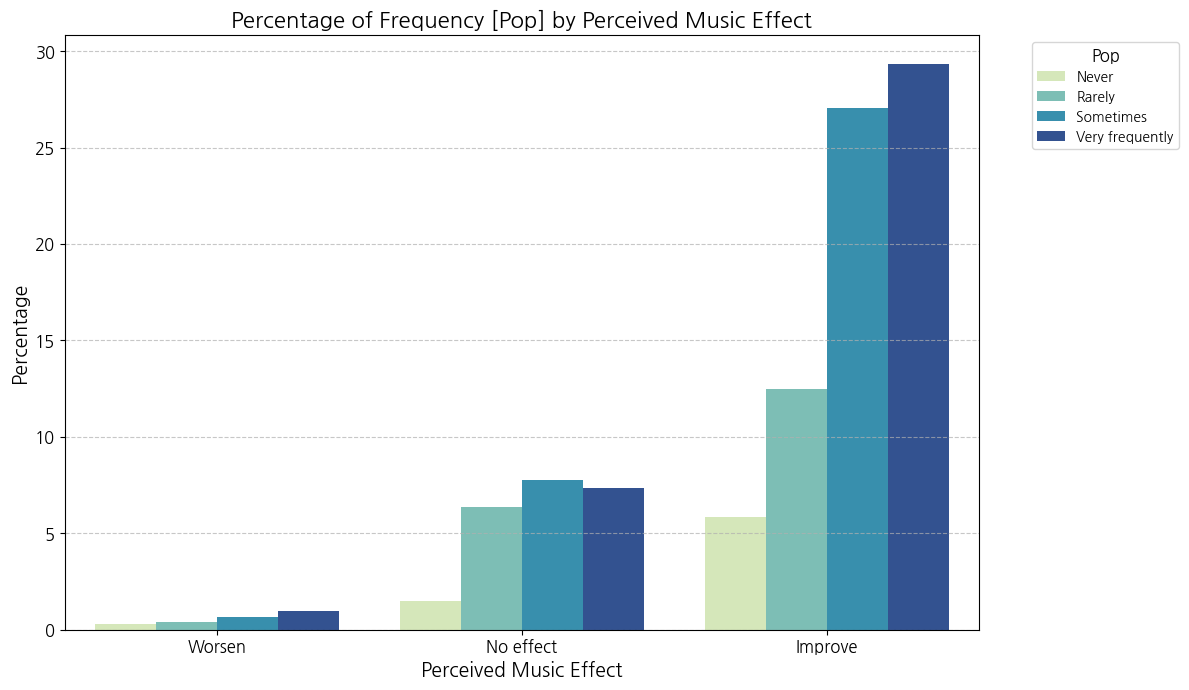

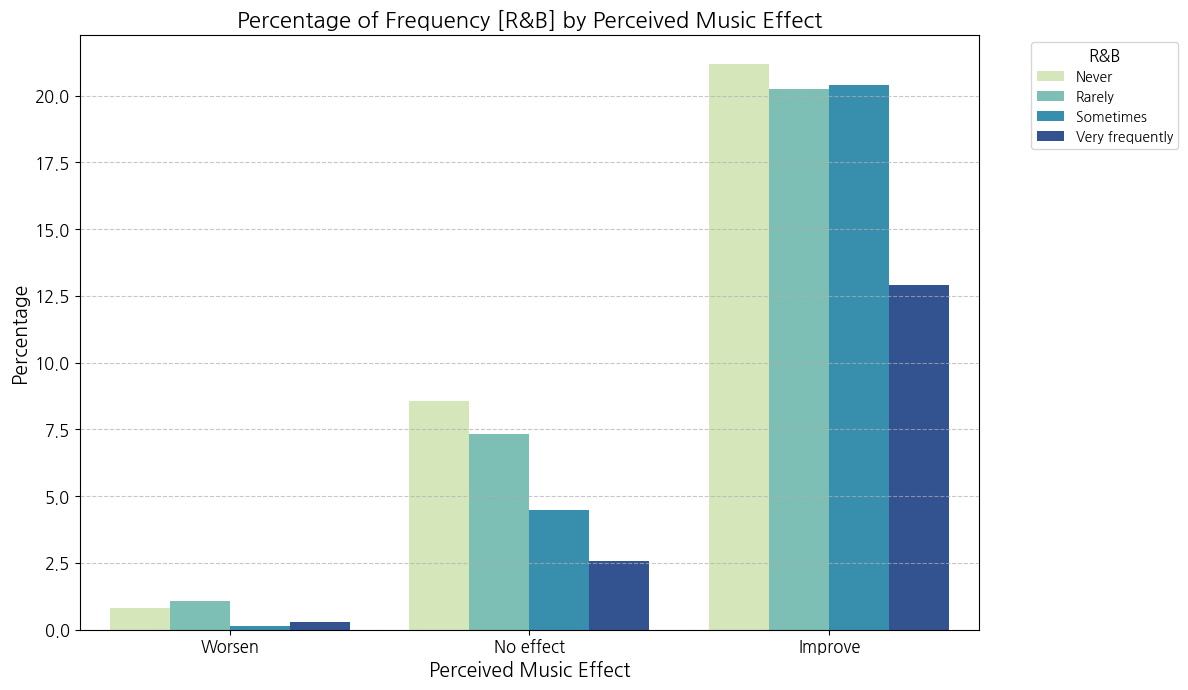

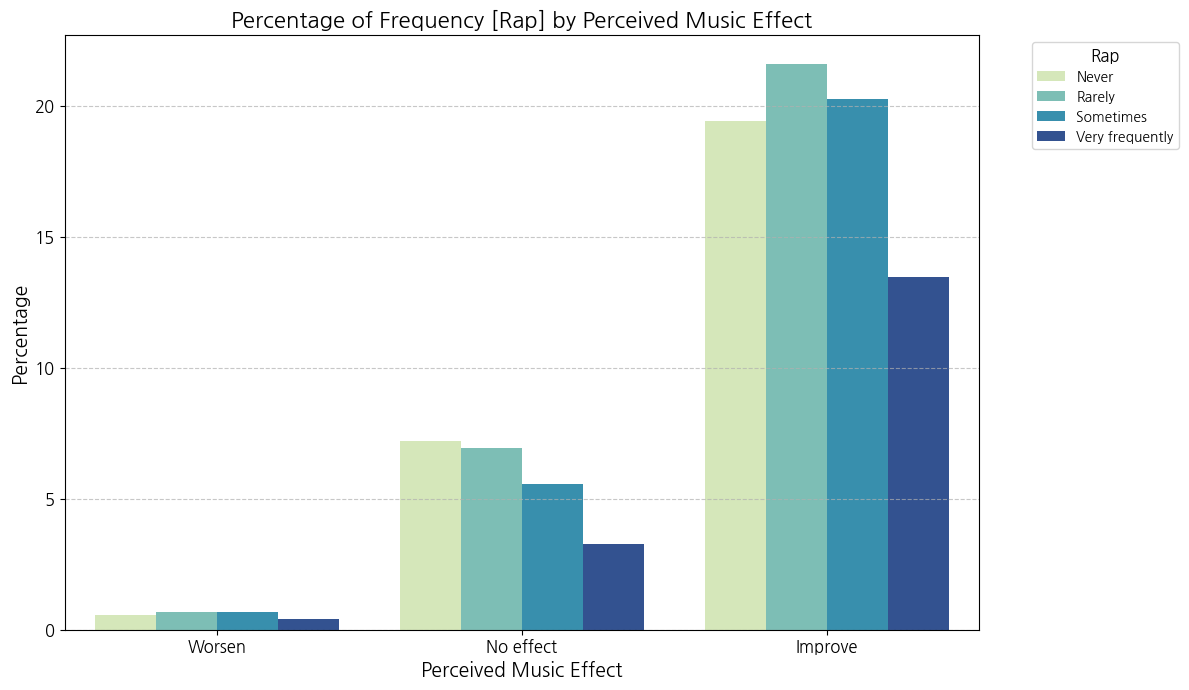

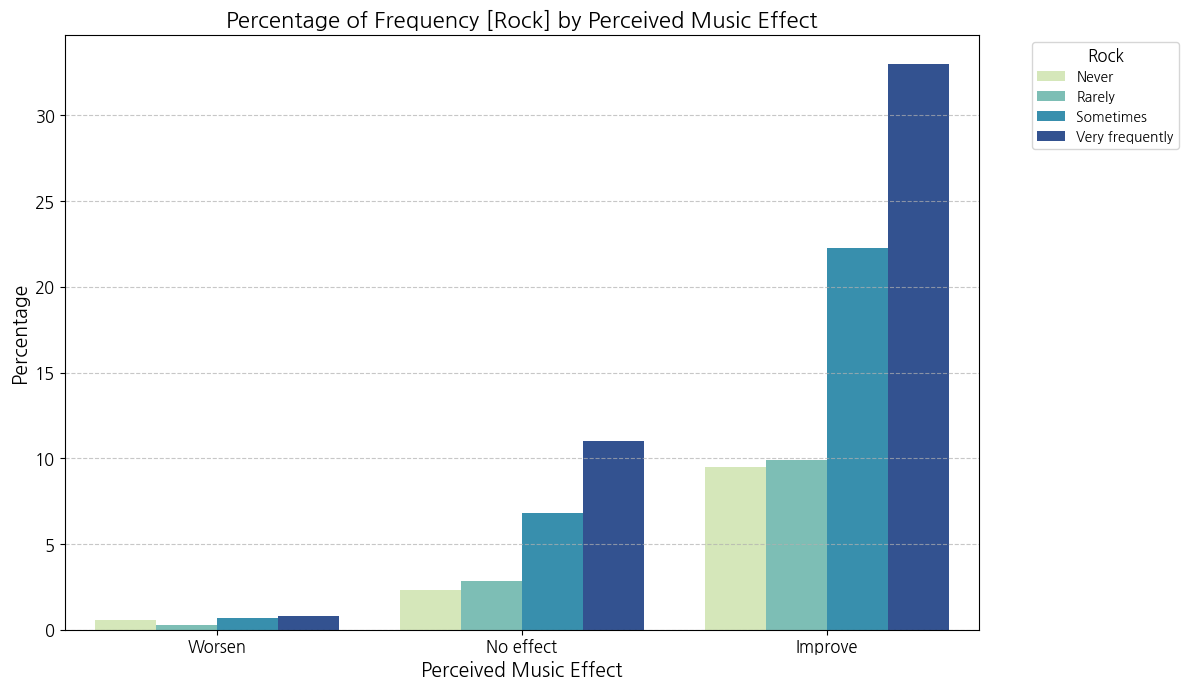

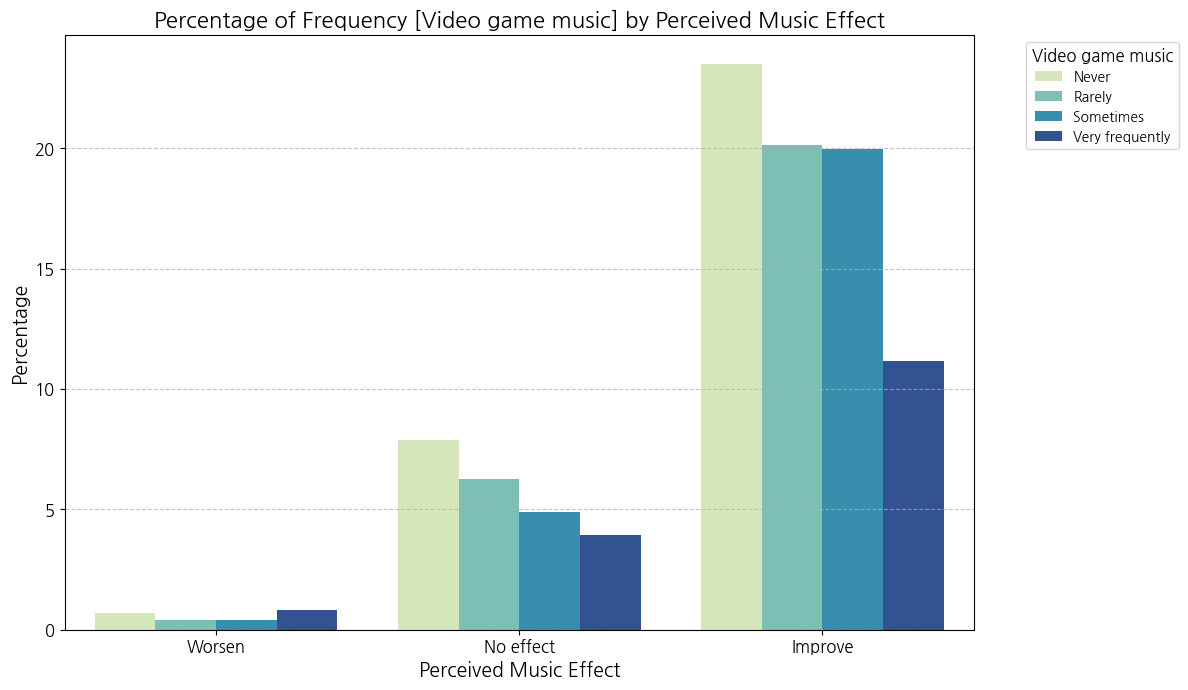

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# df는 여러분의 DataFrame이라고 가정합니다.
# 'Music effects'와 'Fav genre' 컬럼의 결측치 처리 확인 (이전에 하셨을 겁니다)
# df['Music effects'].fillna(df['Music effects'].mode()[0], inplace=True)

# Music effects의 범주 순서 지정
effect_order = ['Worsen', 'No effect', 'Improve']

# --- 1. Music effects 그룹별 Fav genre (선호 장르) 비율 ---
plt.figure(figsize=(14, 8))
sns.countplot(
    data=df,
    x='Music effects',
    hue='Fav genre',
    order=effect_order,
    palette='tab20', # 다양한 장르를 구분하기 위한 넓은 팔레트
    stat='percent' # 비율로 표시
)
plt.title('Percentage of Favorite Genre by Perceived Music Effect', fontsize=16)
plt.xlabel('Perceived Music Effect', fontsize=14)
plt.ylabel('Percentage', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(title='Favorite Genre', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10, title_fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# --- 2. Music effects 그룹별 Frequency [Genre] (장르별 청취 빈도) 비율 ---
# 'Frequency [Genre]' 컬럼 목록 정의
frequency_cols = [col for col in df.columns if col.startswith('Frequency')]

# 'Frequency [Genre]'의 순서 정의 (Never -> Very frequently)
frequency_order = ['Never', 'Rarely', 'Sometimes', 'Very frequently']

for freq_col in frequency_cols:
    # 해당 빈도 컬럼의 결측치 처리 (만약 있다면)
    # df[freq_col].fillna(df[freq_col].mode()[0], inplace=True) # 필요한 경우 주석 해제

    plt.figure(figsize=(12, 7))
    sns.countplot(
        data=df,
        x='Music effects',
        hue=freq_col,
        order=effect_order,
        hue_order=frequency_order, # 빈도 순서 지정
        palette='YlGnBu', # 빈도에 어울리는 색상 팔레트
        stat='percent' # 비율로 표시
    )
    plt.title(f'Percentage of {freq_col} by Perceived Music Effect', fontsize=16)
    plt.xlabel('Perceived Music Effect', fontsize=14)
    plt.ylabel('Percentage', fontsize=14)
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    plt.legend(title=freq_col.replace('Frequency [', '').replace(']', ''), bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10, title_fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

<Figure size 6000x5400 with 0 Axes>

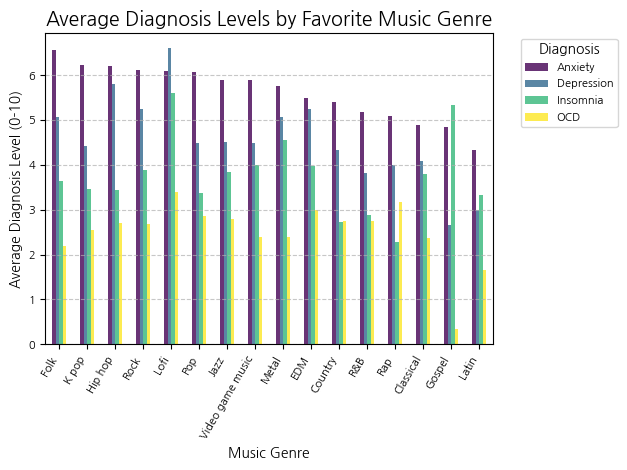

In [35]:
# prompt: ###예시 코드###
# # Calculate the average diagnoses for each favorite genre
# diagnosis_by_genre = df.groupby('Fav genre')[['Anxiety', 'Depression', 'Insomnia', 'OCD']].mean()
# plt.figure(figsize=(16, 10))
# diagnosis_by_genre.plot(kind='bar', cmap='viridis', alpha=0.8)
# plt.title('Average Diagnosis Levels by Favorite Music Genre', fontsize=14)
# plt.xlabel('Music Genre', fontsize=12)
# plt.ylabel('Average Diagnosis Level', fontsize=12)
# plt.xticks(rotation=45)
# plt.legend(title='Diagnosis', fontsize=10, title_fontsize=12, loc=(1.04, 0))
# plt.grid(axis='y', linestyle='--', alpha=0.7)
# plt.show()
# ###질문###
# 예시코드의 시각화를 이 데이터셋에 맞게 수정한 코드

import matplotlib.pyplot as plt
# Calculate the average diagnoses for each favorite genre
diagnosis_by_genre = df.groupby('Fav genre')[['Anxiety', 'Depression', 'Insomnia', 'OCD']].mean()
diagnosis_by_genre = diagnosis_by_genre.sort_values(by='Anxiety', ascending=False) # 불안 지표 기준으로 정렬

plt.figure(figsize=(60, 54)) # 피규어 사이즈 확대
diagnosis_by_genre.plot(kind='bar', cmap='viridis', alpha=0.8)
plt.title('Average Diagnosis Levels by Favorite Music Genre', fontsize=14) # 제목 폰트 크기 확대
plt.xlabel('Music Genre', fontsize=10) # x축 라벨 폰트 크기 확대
plt.ylabel('Average Diagnosis Level (0-10)', fontsize=10) # y축 라벨 폰트 크기 확대, 범위 추가
plt.xticks(rotation=60, ha='right', fontsize=8) # x축 텍스트 회전 및 정렬 조정, 폰트 크기 확대
plt.yticks(fontsize=8) # y축 폰트 크기 확대
plt.legend(title='Diagnosis', fontsize=8, title_fontsize=10, bbox_to_anchor=(1.05, 1), loc='upper left') # 범례 위치 및 폰트 크기 조정
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout() # 레이아웃 자동 조정
plt.show()


# 5. 머신러닝 모델 만들기 : 지도학습
- 정신 건강 상태 예측하기

음악 청취 패턴으로 정신 건강 상태 예측하기

- Anxiety와 Depression이 Worsen 그룹에서 가장 높은 평균과 중앙값을 보여, 모델링의 타겟으로 삼기에 가장 적절함 일단 Anxiety로 결정.
- 모델의 성능 높이기 위해 다른 감정 변수들 변수에 포함시켜야 하나?
==> 이러이러한 음악 청취 패턴을 가지고 있고, 동시에 우울감도 이 정도이며, 불면증도 이 정도인 사람의 불안 수준은 이럴 것이다

In [36]:

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report


In [37]:
# 필요한 컬럼 정의
freq_cols = [col for col in df.columns if col.startswith("Frequency")]
cols_to_use = ['Age', 'Primary streaming service', 'Hours per day', 'Fav genre',
               'Instrumentalist', 'Composer', 'While working', 'Exploratory',
               'Foreign languages', 'Music effects', 'Depression', 'Insomnia', 'OCD'] + freq_cols + ['Anxiety']

data = df[cols_to_use].copy()

# Anxiety 분류로 변환
def anxiety_category(score):
    if score <= 3:
        return 0
    elif score <= 6:
        return 1
    else:
        return 2

data['Anxiety_Level'] = data['Anxiety'].apply(anxiety_category)
data = data.drop('Anxiety', axis=1)

# 범주형 인코딩
for col in data.columns:
    if data[col].dtype == 'object':
        le = LabelEncoder()
        data[col] = le.fit_transform(data[col])

X = data.drop('Anxiety_Level', axis=1)
y = data['Anxiety_Level']

X.columns = X.columns.str.replace(r'[\[\]<>]', '', regex=True)
# 중복 컬럼명 처리 (XGBoost는 중복 컬럼명에 민감할 수 있음)
cols = pd.Series(X.columns)
for dup in cols[cols.duplicated()].unique():
    cols[cols[cols == dup].index.values.tolist()] = [dup + '_' + str(i) if i != 0 else dup for i, _ in enumerate(cols[cols == dup].index)]
X.columns = cols

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 5-1 : RandomForeest

In [38]:
# --- 1. 기본 모델 학습 및 성능 평가 ---
print("--- 기본 모델 성능 ---")
rf_base = RandomForestClassifier(random_state=42)
rf_base.fit(X_train, y_train)
y_pred_base = rf_base.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_base))
print("F1-score:", f1_score(y_test, y_pred_base, average='weighted'))
print(classification_report(y_test, y_pred_base))

# --- 2. 하이퍼파라미터 튜닝된 모델 학습 및 성능 평가 (GridSearchCV) ---
print("\n--- 튜닝된 모델 성능 (GridSearchCV) ---")
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

grid_search = GridSearchCV(RandomForestClassifier(random_state=42),
                           param_grid, cv=3, scoring='f1_weighted', n_jobs=-1)

grid_search.fit(X_train, y_train)

best_rf = grid_search.best_estimator_
y_pred_best = best_rf.predict(X_test)

print("최적 하이퍼파라미터:", grid_search.best_params_)
print("Accuracy:", accuracy_score(y_test, y_pred_best))
print("F1-score:", f1_score(y_test, y_pred_best, average='weighted'))
print(classification_report(y_test, y_pred_best))

--- 기본 모델 성능 ---
Accuracy: 0.6148648648648649
F1-score: 0.5866919410916643
              precision    recall  f1-score   support

           0       0.64      0.58      0.61        36
           1       0.56      0.25      0.34        40
           2       0.62      0.83      0.71        72

    accuracy                           0.61       148
   macro avg       0.60      0.56      0.55       148
weighted avg       0.61      0.61      0.59       148


--- 튜닝된 모델 성능 (GridSearchCV) ---
최적 하이퍼파라미터: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 100}
Accuracy: 0.5878378378378378
F1-score: 0.5498679806559332
              precision    recall  f1-score   support

           0       0.57      0.47      0.52        36
           1       0.47      0.20      0.28        40
           2       0.61      0.86      0.72        72

    accuracy                           0.59       148
   macro avg       0.55      0.51      0.50       148
weighted avg       0.56      0.59      0.55       1

# 5-1-1 : RandomForeest SMOTE 튜닝

In [39]:
# SMOTE (Synthetic Minority Oversampling Technique)로 정확도 더 올려보기

In [40]:
from imblearn.over_sampling import SMOTE
# SMOTE 적용 (훈련 데이터만!)
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# 기본 모델 학습
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train_resampled, y_train_resampled)
y_pred = rf.predict(X_test)

print("=== 기본 모델 성능 (SMOTE 적용) ===")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1-score:", f1_score(y_test, y_pred, average='weighted'))
print(classification_report(y_test, y_pred))

# 하이퍼파라미터 튜닝
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=3,
    scoring='f1_weighted',
    n_jobs=-1
)

grid_search.fit(X_train_resampled, y_train_resampled)

# 최적 모델 평가
best_rf = grid_search.best_estimator_
y_pred_best = best_rf.predict(X_test)

print("=== 튜닝된 모델 성능 (SMOTE 적용) ===")
print("최적 하이퍼파라미터:", grid_search.best_params_)
print("Accuracy:", accuracy_score(y_test, y_pred_best))
print("F1-score:", f1_score(y_test, y_pred_best, average='weighted'))
print(classification_report(y_test, y_pred_best))

=== 기본 모델 성능 (SMOTE 적용) ===
Accuracy: 0.581081081081081
F1-score: 0.572664213509284
              precision    recall  f1-score   support

           0       0.63      0.61      0.62        36
           1       0.41      0.33      0.36        40
           2       0.63      0.71      0.67        72

    accuracy                           0.58       148
   macro avg       0.55      0.55      0.55       148
weighted avg       0.57      0.58      0.57       148

=== 튜닝된 모델 성능 (SMOTE 적용) ===
최적 하이퍼파라미터: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
Accuracy: 0.6081081081081081
F1-score: 0.5993330993330993
              precision    recall  f1-score   support

           0       0.61      0.61      0.61        36
           1       0.50      0.38      0.43        40
           2       0.65      0.74      0.69        72

    accuracy                           0.61       148
   macro avg       0.59      0.57      0.58       148
weighted avg       0.60      0.61      0.60  

In [41]:
# SMOTE 적용 + 튜닝을 했음에도 성능 개선이 거의 없고 하락!

# 5-2 : XGBClassifer

In [42]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, classification_report
from xgboost import XGBClassifier


# --- 1. 기본 XGBoost 모델 학습 및 성능 평가 ---
print("--- XGBoost 기본 모델 성능 ---")
# use_label_encoder=False와 eval_metric='mlogloss'는 최신 XGBoost 버전에서 권장되는 설정
xgb_base = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42)
xgb_base.fit(X_train, y_train)
y_pred_base = xgb_base.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_base))
print("F1-score:", f1_score(y_test, y_pred_base, average='weighted'))
print(classification_report(y_test, y_pred_base))

# --- 2. 하이퍼파라미터 튜닝된 XGBoost 모델 학습 및 성능 평가 (GridSearchCV) ---
print("\n--- XGBoost 튜닝된 모델 성능 (GridSearchCV) ---")
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.05, 0.1, 0.2],
    'subsample': [0.8, 1.0]
}

grid_search = GridSearchCV(
    estimator=XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42),
    param_grid=param_grid,
    scoring='f1_weighted', # 클래스 불균형을 고려하여 f1_weighted 사용
    cv=3, # 3-fold 교차 검증
    n_jobs=-1 # 모든 CPU 코어 사용
)

grid_search.fit(X_train, y_train)

# 최적 모델로 예측
best_xgb = grid_search.best_estimator_
y_pred_best = best_xgb.predict(X_test)

print("최적 하이퍼파라미터:", grid_search.best_params_)
print("Accuracy:", accuracy_score(y_test, y_pred_best))
print("F1-score:", f1_score(y_test, y_pred_best, average='weighted'))
print(classification_report(y_test, y_pred_best))

--- XGBoost 기본 모델 성능 ---


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [04:17:05] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Accuracy: 0.5540540540540541
F1-score: 0.5360156495628687
              precision    recall  f1-score   support

           0       0.56      0.39      0.46        36
           1       0.38      0.30      0.33        40
           2       0.62      0.78      0.69        72

    accuracy                           0.55       148
   macro avg       0.52      0.49      0.49       148
weighted avg       0.54      0.55      0.54       148


--- XGBoost 튜닝된 모델 성능 (GridSearchCV) ---


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [04:17:25] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


최적 하이퍼파라미터: {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 100, 'subsample': 0.8}
Accuracy: 0.5675675675675675
F1-score: 0.5557640600862637
              precision    recall  f1-score   support

           0       0.60      0.42      0.49        36
           1       0.39      0.35      0.37        40
           2       0.63      0.76      0.69        72

    accuracy                           0.57       148
   macro avg       0.54      0.51      0.52       148
weighted avg       0.56      0.57      0.56       148



# 5-3 : LightGBM

In [43]:
from lightgbm import LGBMClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, f1_score, classification_report

# 기본 LightGBM 모델 학습
lgbm = LGBMClassifier(random_state=42)
lgbm.fit(X_train, y_train)
y_pred = lgbm.predict(X_test)

print("=== LightGBM 기본 모델 성능 ===")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1-score:", f1_score(y_test, y_pred, average='weighted'))
print(classification_report(y_test, y_pred))

# 하이퍼파라미터 튜닝
param_grid_lgbm = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, 15],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8, 1.0]
}

grid_lgbm = GridSearchCV(
    LGBMClassifier(random_state=42),
    param_grid_lgbm,
    scoring='f1_weighted',
    cv=3,
    n_jobs=-1
)

grid_lgbm.fit(X_train_resampled, y_train_resampled)

best_lgbm = grid_lgbm.best_estimator_
y_pred_best = best_lgbm.predict(X_test)

print("=== LightGBM 튜닝된 모델 성능 ===")
print("최적 하이퍼파라미터:", grid_lgbm.best_params_)
print("Accuracy:", accuracy_score(y_test, y_pred_best))
print("F1-score:", f1_score(y_test, y_pred_best, average='weighted'))
print(classification_report(y_test, y_pred_best))


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000827 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 194
[LightGBM] [Info] Number of data points in the train set: 588, number of used features: 29
[LightGBM] [Info] Start training from score -1.427967
[LightGBM] [Info] Start training from score -1.314132
[LightGBM] [Info] Start training from score -0.710300
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further s

# 5-5 : CatBoost

In [44]:
from catboost import CatBoostClassifier

# 기본 CatBoost 모델 학습
cat = CatBoostClassifier(verbose=0, random_state=42)
cat.fit(X_train, y_train)
y_pred = cat.predict(X_test)

print("=== CatBoost 기본 모델 성능 ===")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1-score:", f1_score(y_test, y_pred, average='weighted'))
print(classification_report(y_test, y_pred))

# 하이퍼파라미터 튜닝
param_grid_cat = {
    'iterations': [100, 200],
    'depth': [5, 8, 10],
    'learning_rate': [0.05, 0.1],
    'l2_leaf_reg': [1, 3, 5]
}

grid_cat = GridSearchCV(
    CatBoostClassifier(verbose=0, random_state=42),
    param_grid_cat,
    scoring='f1_weighted',
    cv=3,
    n_jobs=-1
)

grid_cat.fit(X_train_resampled, y_train_resampled)

best_cat = grid_cat.best_estimator_
y_pred_best = best_cat.predict(X_test)

print("=== CatBoost 튜닝된 모델 성능 ===")
print("최적 하이퍼파라미터:", grid_cat.best_params_)
print("Accuracy:", accuracy_score(y_test, y_pred_best))
print("F1-score:", f1_score(y_test, y_pred_best, average='weighted'))
print(classification_report(y_test, y_pred_best))


=== CatBoost 기본 모델 성능 ===
Accuracy: 0.581081081081081
F1-score: 0.5672971107753716
              precision    recall  f1-score   support

           0       0.63      0.47      0.54        36
           1       0.41      0.33      0.36        40
           2       0.63      0.78      0.70        72

    accuracy                           0.58       148
   macro avg       0.56      0.53      0.53       148
weighted avg       0.57      0.58      0.57       148

=== CatBoost 튜닝된 모델 성능 ===
최적 하이퍼파라미터: {'depth': 10, 'iterations': 200, 'l2_leaf_reg': 1, 'learning_rate': 0.1}
Accuracy: 0.5472972972972973
F1-score: 0.5463625105683271
              precision    recall  f1-score   support

           0       0.60      0.50      0.55        36
           1       0.39      0.40      0.40        40
           2       0.61      0.65      0.63        72

    accuracy                           0.55       148
   macro avg       0.53      0.52      0.52       148
weighted avg       0.55      0.55      0

| 모델           | SMOTE 적용 | 최적 하이퍼파라미터                                                                       | Accuracy | F1-score | Precision (0) | Precision (1) | Precision (2) | Recall (0) | Recall (1) | Recall (2) | F1 (0) | F1 (1) | F1 (2) |
| ------------ | -------- | -------------------------------------------------------------------------------- | -------- | -------- | ------------- | ------------- | ------------- | ---------- | ---------- | ---------- | ------ | ------ | ------ |
| RandomForest | 기본       | {'max\_depth': None, 'min\_samples\_split': 2, 'n\_estimators': 100}             | 0.615    | 0.587    | 0.64          | 0.56          | 0.62          | 0.58       | 0.25       | 0.83       | 0.61   | 0.34   | 0.71   |
| RandomForest | 튜닝       | {'max\_depth': 10, 'min\_samples\_split': 2, 'n\_estimators': 100}               | 0.588    | 0.550    | 0.57          | 0.47          | 0.61          | 0.47       | 0.20       | 0.86       | 0.52   | 0.28   | 0.72   |
| RandomForest | SMOTE 적용 | {'max\_depth': None, 'min\_samples\_split': 2, 'n\_estimators': 100}             | 0.581    | 0.573    | 0.63          | 0.41          | 0.63          | 0.61       | 0.33       | 0.71       | 0.62   | 0.36   | 0.67   |
| RandomForest | SMOTE 튜닝 | {'max\_depth': None, 'min\_samples\_split': 2, 'n\_estimators': 200}             | 0.608    | 0.599    | 0.61          | 0.50          | 0.65          | 0.61       | 0.38       | 0.74       | 0.61   | 0.43   | 0.69   |
| XGBoost      | 기본       | -                                                                                | 0.554    | 0.536    | 0.56          | 0.38          | 0.62          | 0.39       | 0.30       | 0.78       | 0.46   | 0.33   | 0.69   |
| XGBoost      | 튜닝       | {'learning\_rate': 0.1, 'max\_depth': 7, 'n\_estimators': 100, 'subsample': 0.8} | 0.568    | 0.556    | 0.60          | 0.39          | 0.63          | 0.42       | 0.35       | 0.76       | 0.49   | 0.37   | 0.69   |
| LightGBM     | 기본       | -                                                                                | 0.568    | 0.553    | 0.57          | 0.45          | 0.61          | 0.47       | 0.33       | 0.75       | 0.52   | 0.38   | 0.67   |
| LightGBM     | 튜닝       | {'learning\_rate': 0.1, 'max\_depth': 5, 'n\_estimators': 200, 'subsample': 0.8} | 0.534    | 0.521    | 0.52          | 0.39          | 0.59          | 0.39       | 0.33       | 0.72       | 0.44   | 0.36   | 0.65   |
| CatBoost     | 기본       | -                                                                                | 0.581    | 0.567    | 0.63          | 0.41          | 0.63          | 0.47       | 0.33       | 0.78       | 0.54   | 0.36   | 0.70   |
| CatBoost     | 튜닝       | {'depth': 10, 'iterations': 200, 'l2\_leaf\_reg': 1, 'learning\_rate': 0.1}      | 0.547    | 0.546    | 0.60          | 0.39          | 0.61          | 0.50       | 0.40       | 0.65       | 0.55   | 0.40   | 0.63   |


In [45]:
# 현재 데이터와 변수로는 예측 정확도에 한계가 있는듯.

1. 분석 목적
- 설문 응답자의 음악 청취 습관과 심리 상태 데이터를 바탕으로, 불안 수준(Anxiety Level) 을 세 가지 범주(낮음, 중간, 높음) 로 분류하는 분류 모델을 개발하는 것이 목표
2. 데이터 구성 및 전처리
- Anxiety 점수를 기준으로 세 가지 범주로 분류
- 범주 간 데이터 불균형을 해결하기 위해 SMOTE 오버샘플링 기법을 사용 : 효과 미미해서 다른 모델들은 안 써줌
- 여러 범주형 변수를 Label Encoding을 통해 처리함
3. 모델
- RandomForest, XGBoost, LightGBM, CatBoost 사용
- XGBoost와 CatBoost 기본 모델이 가장 좋은 성능
-- XGBoost와 CatBoost는 튜닝 전 상태에서 안정적인 F1-score를 보임
- 60%의 정확도, 약 0.59 수준의 F1-score
4. 모델 성능의 한계
- 중간 불안 상태(클래스 1)의 예측이 consistently 낮은 f1-score
- 모델의 문제가 아니라, 해당 범주의 구분이 데이터상 명확하지 않다

#6. 머신러닝 모델 만들기 : 비지도학습
- 유사한 정신 건강 상태 그룹(Cluster) 분류 -> 군집 정보를 기반으로 그룹을 예측하는 모델

# 6-1 KMeans 군집화
- 엘보우 메서드 그래프
- 군집별 특성 (정신 건강 지표) 평균 출력
- 군집별 다른 특성 분포 시각화
- 군집을 기반으로 한 예측 모델(KNN)

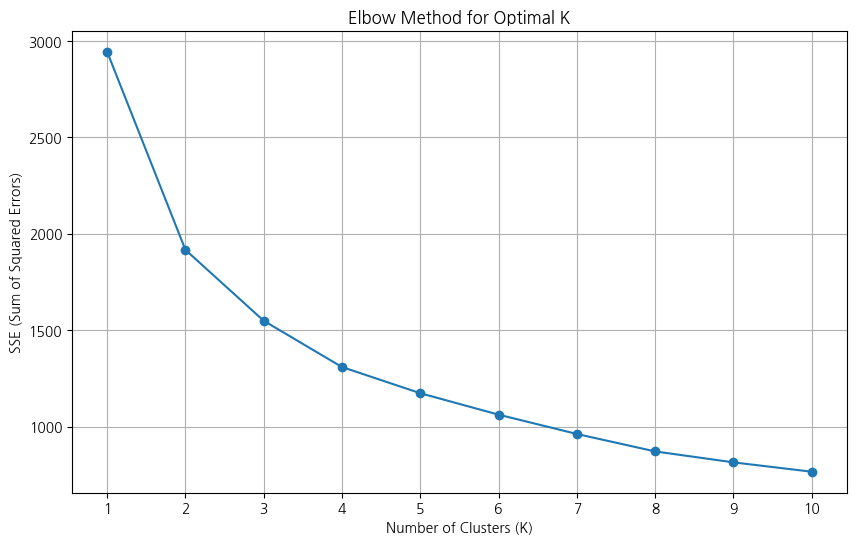


--- Cluster Summary (Average Mental Health Indicators) ---
          Anxiety  Depression  Insomnia       OCD
Cluster                                          
0        7.657895    5.766082  5.014620  6.900585
1        3.494845    2.247423  1.786942  1.178694
2        7.189781    6.897810  5.014599  1.525547


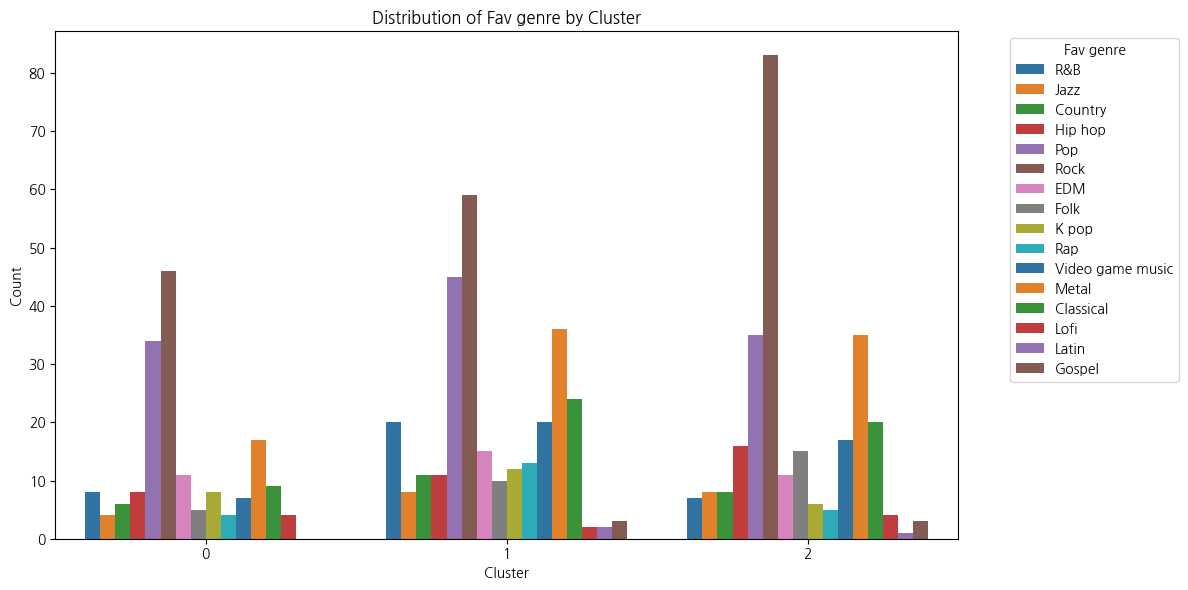

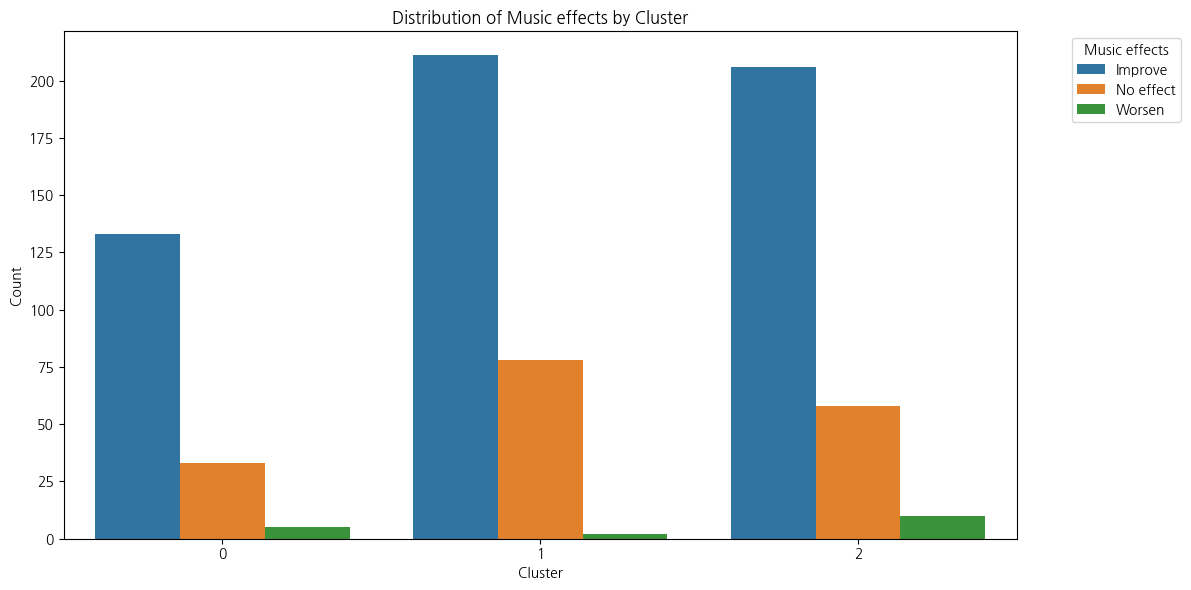

/tmp/ipython-input-46-2838174265.py:66: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Cluster', y=col, palette='viridis')


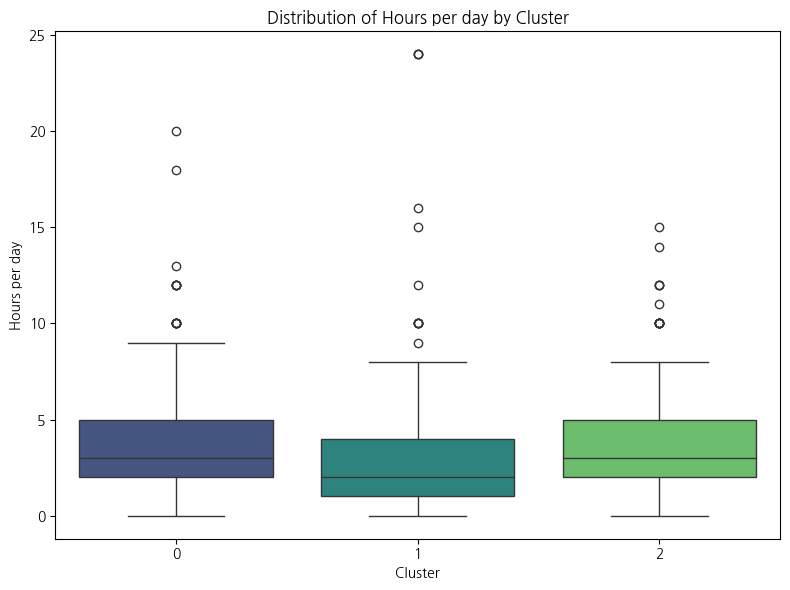


--- Cluster Distribution in Training Data ---
Cluster
1    232
2    219
0    137
Name: count, dtype: int64

--- Cluster Distribution in Resampled Training Data ---
Cluster
1    232
2    232
0    232
Name: count, dtype: int64

=== CatBoost Cluster Prediction Model Performance ===
Accuracy: 0.8716216216216216
F1-score (weighted): 0.8713115593408555
              precision    recall  f1-score   support

           0       0.89      0.91      0.90        34
           1       0.86      0.83      0.84        59
           2       0.88      0.89      0.88        55

    accuracy                           0.87       148
   macro avg       0.87      0.88      0.88       148
weighted avg       0.87      0.87      0.87       148



In [46]:
import pandas as pd
import matplotlib.pyplot as plt
# 비지도학습을 위한 그룹화부터

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# 군집화에 사용할 컬럼 정의 (정신 건강 관련 수치형 변수)
clustering_cols = ['Anxiety', 'Depression', 'Insomnia', 'OCD']

# 해당 컬럼들만 추출
df_clustering = df[clustering_cols].copy()

# 스케일링 (KMeans는 스케일에 민감)
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_clustering)
df_scaled = pd.DataFrame(df_scaled, columns=clustering_cols) # 다시 DataFrame으로 변환

# 적절한 군집 개수(K) 찾기 - 엘보우 메서드
sse = []
k_range = range(1, 11)
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10) # n_init 명시
    kmeans.fit(df_scaled)
    sse.append(kmeans.inertia_) # inertia는 Within-cluster sum of squares

plt.figure(figsize=(10, 6))
plt.plot(k_range, sse, marker='o')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('SSE (Sum of Squared Errors)')
plt.xticks(k_range)
plt.grid(True)
plt.show()

# 엘보우 메서드 결과에 따라 K=3 또는 K=4로 결정 가능. 여기서는 K=3으로 진행.
# 실제 군집화 실행
n_clusters = 3 # 엘보우 포인트를 보고 결정
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10) # n_init 명시
df['Cluster'] = kmeans.fit_predict(df_scaled)

#각 군집의 특성 확인 (정신 건강 지표 평균)
cluster_summary = df.groupby('Cluster')[clustering_cols].mean()
print("\n--- Cluster Summary (Average Mental Health Indicators) ---")
print(cluster_summary)

# 군집별 분포 시각화 (산점도 행렬)
# sns.pairplot(df, vars=clustering_cols, hue='Cluster', palette='viridis')
# plt.suptitle('Pairplot of Mental Health Indicators by Cluster', y=1.02)
# plt.show()

# 군집별 다른 특성 분포 확인 (예: Fav genre, Music effects)
for col in ['Fav genre', 'Music effects', 'Hours per day']:
    if col in df.columns:
        if df[col].dtype == 'object': # 범주형
            plt.figure(figsize=(12, 6))
            sns.countplot(data=df, x='Cluster', hue=col, palette='tab10')
            plt.title(f'Distribution of {col} by Cluster')
            plt.xlabel('Cluster')
            plt.ylabel('Count')
            plt.legend(title=col, bbox_to_anchor=(1.05, 1), loc='upper left')
            plt.tight_layout()
            plt.show()
        else: # 수치형
             plt.figure(figsize=(8, 6))
             sns.boxplot(data=df, x='Cluster', y=col, palette='viridis')
             plt.title(f'Distribution of {col} by Cluster')
             plt.xlabel('Cluster')
             plt.ylabel(col)
             plt.tight_layout()
             plt.show()

# 새로운 군집 라벨을 사용한 예측 모델
# 타겟을 새로 생성된 'Cluster' 컬럼으로 변경
X = data.drop(['Anxiety_Level'], axis=1).copy() # 기존 Anxiety_Level 제거
y = df['Cluster'].copy() # 새로운 타겟: Cluster

# 특수문자 컬럼 제거 (재실행 시 필요)
X.columns = X.columns.str.replace(r'[\[\]<>]', '', regex=True)

# Train/Test 분리
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

# SMOTE 적용 (군집 라벨 불균형 확인 후 필요시 적용)
print("\n--- Cluster Distribution in Training Data ---")
print(y_train.value_counts())

# 군집 불균형이 있다면 SMOTE 적용
smote = SMOTE(random_state=42)
X_train_resampled_np, y_train_resampled = smote.fit_resample(X_train, y_train)
X_train_resampled = pd.DataFrame(X_train_resampled_np, columns=X_train.columns)

print("\n--- Cluster Distribution in Resampled Training Data ---")
print(y_train_resampled.value_counts())

# CatBoost 모델 학습 (군집 예측)
cat_cluster = CatBoostClassifier(verbose=0, random_state=42)
cat_cluster.fit(X_train_resampled, y_train_resampled)
y_pred_cluster = cat_cluster.predict(X_test)

print("\n=== CatBoost Cluster Prediction Model Performance ===")
print("Accuracy:", accuracy_score(y_test, y_pred_cluster))
print("F1-score (weighted):", f1_score(y_test, y_pred_cluster, average='weighted'))
print(classification_report(y_test, y_pred_cluster))


- KMeans 군집화 결과를 2차원으로 축소하고, 시각화

- Kmeans 모델의 결과에 대한 바이올린 플롯 시각화 코드

/tmp/ipython-input-47-3943960379.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipython-input-47-3943960379.py:22: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) NanumGothic.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) NanumGothic.
  fig.canvas.print_figure(bytes_io, **kw)


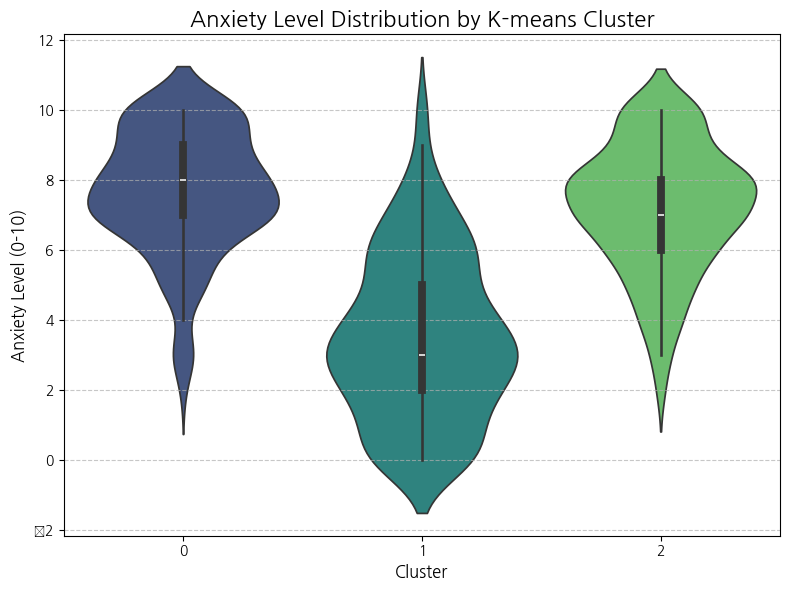

/tmp/ipython-input-47-3943960379.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipython-input-47-3943960379.py:22: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) NanumGothic.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) NanumGothic.
  fig.canvas.print_figure(bytes_io, **kw)


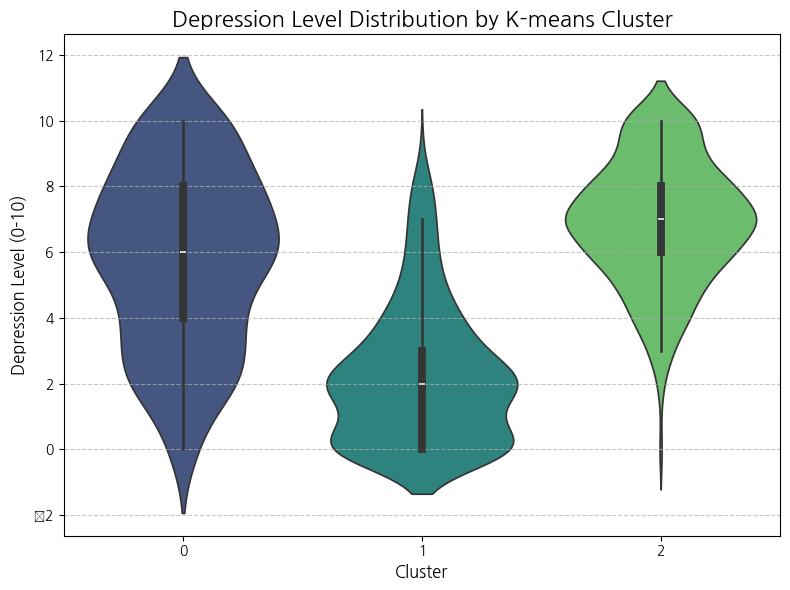

/tmp/ipython-input-47-3943960379.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipython-input-47-3943960379.py:22: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) NanumGothic.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) NanumGothic.
  fig.canvas.print_figure(bytes_io, **kw)


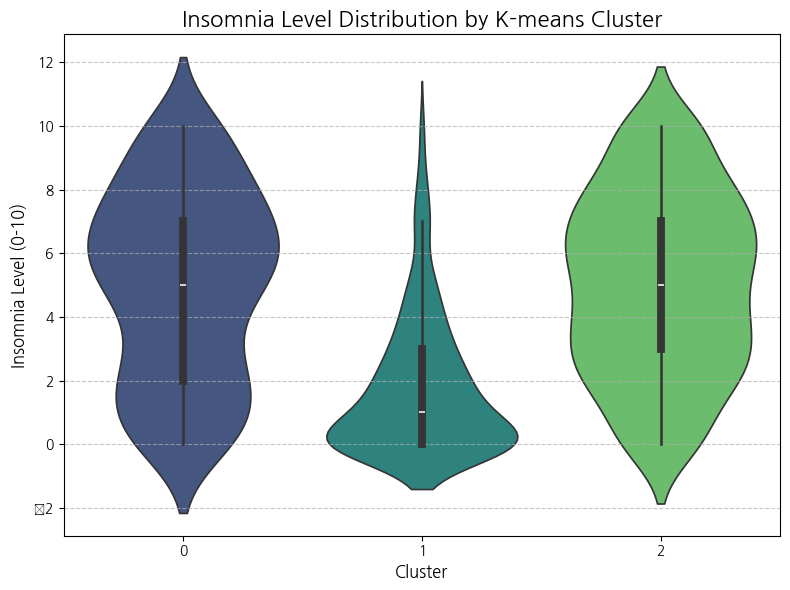

/tmp/ipython-input-47-3943960379.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


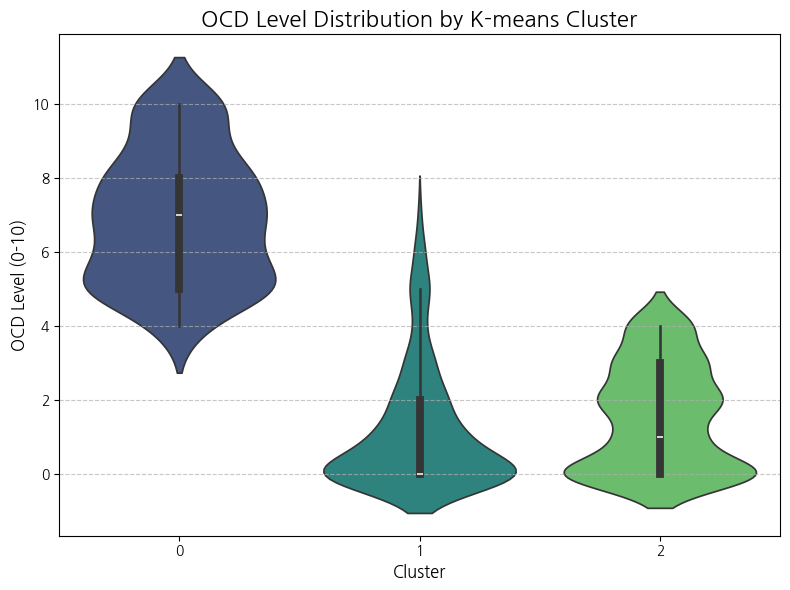

In [47]:
import matplotlib.pyplot as plt
# KNN 군집 결과를 정신 건강 지표별로 바이올린 플롯 시각화

mental_health_indicators = ['Anxiety', 'Depression', 'Insomnia', 'OCD']
n_clusters = df['Cluster'].nunique() # 실제 군집 개수 가져오기
palette = sns.color_palette('viridis', n_clusters) # 군집 개수에 맞는 색상 팔레트 생성

for indicator in mental_health_indicators:
    plt.figure(figsize=(8, 6))
    sns.violinplot(
        x='Cluster',           # x축: 군집 라벨
        y=indicator,         # y축: 정신 건강 지표
        data=df,               # 원본 데이터 사용
        palette=palette        # 군집별 색상 적용
    )
    plt.title(f'{indicator} Level Distribution by K-means Cluster', fontsize=16)
    plt.xlabel('Cluster', fontsize=12)
    plt.ylabel(f'{indicator} Level (0-10)', fontsize=12)
    plt.xticks(fontsize=10)
    plt.yticks(fontsize=10)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()


- kmeans 모델에 대한 feature별 중요도 지수 확인 코드

/usr/local/lib/python3.11/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) NanumGothic.
  fig.canvas.print_figure(bytes_io, **kw)


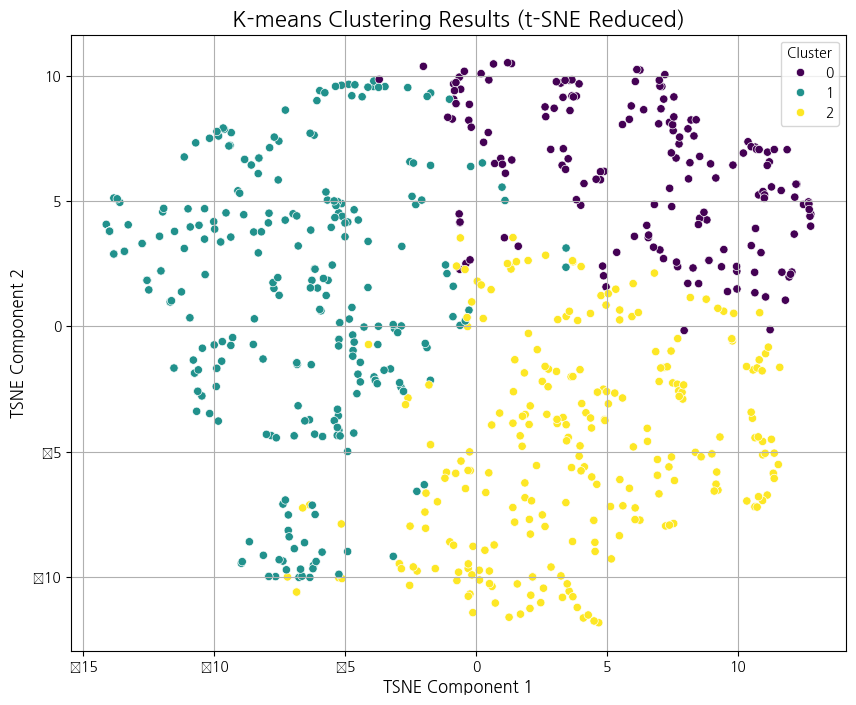

In [48]:
import pandas as pd
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns

# K-means 모델링 결과 (군집 라벨)를 사용하여 시각화 (t-SNE 사용)

# 군집화에 사용된 스케일링된 데이터 또는 원본 데이터 사용 가능.
# 시각화의 목적에 따라 선택합니다. 여기서는 군집화에 사용된 스케일링 데이터를 사용합니다.
# 만약 t-SNE를 원본 데이터에 적용하려면 df_clustering을 사용하고 필요시 스케일링 합니다.
# 이미 스케일링된 df_scaled에 군집 결과를 결합합니다.
df_scaled_with_cluster = pd.DataFrame(df_scaled, columns=clustering_cols)
df_scaled_with_cluster['Cluster'] = df['Cluster']

# t-SNE 적용
# t-SNE는 고차원 데이터를 2차원으로 축소하여 시각화하는 기법입니다.
# n_components: 시각화할 차원 수 (일반적으로 2 또는 3)
# perplexity: 이웃의 수 (일반적으로 5에서 50 사이) - 데이터의 복잡성에 따라 조정
# n_iter: 최적화 반복 횟수
# random_state: 재현성을 위한 값
tsne = TSNE(n_components=2, perplexity=30, n_iter=300, random_state=42)
tsne_results = tsne.fit_transform(df_scaled) # 스케일링된 데이터에 t-SNE 적용

# t-SNE 결과를 DataFrame에 추가
df_tsne = pd.DataFrame(tsne_results, columns=['TSNE Component 1', 'TSNE Component 2'])
df_tsne['Cluster'] = df['Cluster'] # K-means 군집 결과 라벨 추가

# t-SNE 결과를 클러스터별로 시각화
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='TSNE Component 1',
    y='TSNE Component 2',
    hue='Cluster', # K-means 군집 결과에 따라 색상 구분
    data=df_tsne,
    palette='viridis', # 색상 팔레트 선택
    legend='full'
)
plt.title('K-means Clustering Results (t-SNE Reduced)', fontsize=16)
plt.xlabel('TSNE Component 1', fontsize=12)
plt.ylabel('TSNE Component 2', fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.grid(True)
plt.show()



# 6-2 KNN 모델

In [49]:
import matplotlib.pyplot as plt
# KNN 모델은 자체적으로 피처 중요도를 직접적으로 제공하지 않습니다.
# K-NN은 거리 기반 알고리즘으로, 각 피처에 가중치를 할당하는 방식이 아니기 때문입니다.
# 대신, 피처 중요도를 간접적으로 측정하는 몇 가지 방법이 있습니다.

# 1. Permutation Importance (순열 중요도): 모델 성능에 미치는 각 피처의 영향력을 측정
# 2. Backward Elimination (후진 소거법): 피처를 하나씩 제거하며 모델 성능 변화를 확인
# 3. 모델 해석 가능한 다른 모델 사용: RandomForest, LightGBM, XGBoost 등은 자체적으로 피처 중요도를 제공합니다.

# 여기서는 Permutation Importance를 사용하는 예시를 보여드리겠습니다.
# Permutation Importance를 사용하려면 `eli5` 라이브러리나 `sklearn.inspection`의 `permutation_importance`를 사용할 수 있습니다.
# 여기서는 `sklearn` 내장 기능을 사용합니다.

!pip install scikit-learn

from sklearn.neighbors import KNeighborsClassifier
from sklearn.inspection import permutation_importance

# KNN 모델 정의 (이전에 학습된 데이터 X_train, y_train 사용)
knn = KNeighborsClassifier(n_neighbors=5) # 예시 K값, 실제 모델 K값 사용
knn.fit(X_train, y_train) # KNN 모델 학습

# Permutation Importance 계산
# n_repeats: 각 피처를 섞는 반복 횟수
# random_state: 결과 재현을 위한 시드
# n_jobs: 병렬 처리 코어 수 (-1은 사용 가능한 모든 코어 사용)
result = permutation_importance(
    knn, X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1
)

# 피처 중요도와 표준편차 가져오기
sorted_idx = result.importances_mean.argsort()

print("\n--- KNN Model Permutation Importance ---")
for i in sorted_idx[::-1]: # 중요도 내림차순으로 정렬
    if result.importances_mean[i] > 0: # 중요도가 0보다 큰 피처만 출력
        print(f"{X_test.columns[i]:<30} : {result.importances_mean[i]:.4f} +/- {result.importances_std[i]:.4f}")
    else:
        # 중요도가 0 이하인 피처는 대부분 의미 없으므로 생략 가능
        pass


--- KNN Model Permutation Importance ---
OCD                            : 0.2088 +/- 0.0298
Depression                     : 0.1574 +/- 0.0307
Insomnia                       : 0.0804 +/- 0.0255
Frequency Jazz                 : 0.0054 +/- 0.0124
Hours per day                  : 0.0054 +/- 0.0162
Frequency Metal                : 0.0020 +/- 0.0100
Exploratory                    : 0.0020 +/- 0.0061


/tmp/ipython-input-50-3982685515.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(result.importances[sorted_idx].T, vert=False, labels=X.columns[sorted_idx])
/tmp/ipython-input-50-3982685515.py:6: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) NanumGothic.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) NanumGothic.
  fig.canvas.print_figure(bytes_io, **kw)


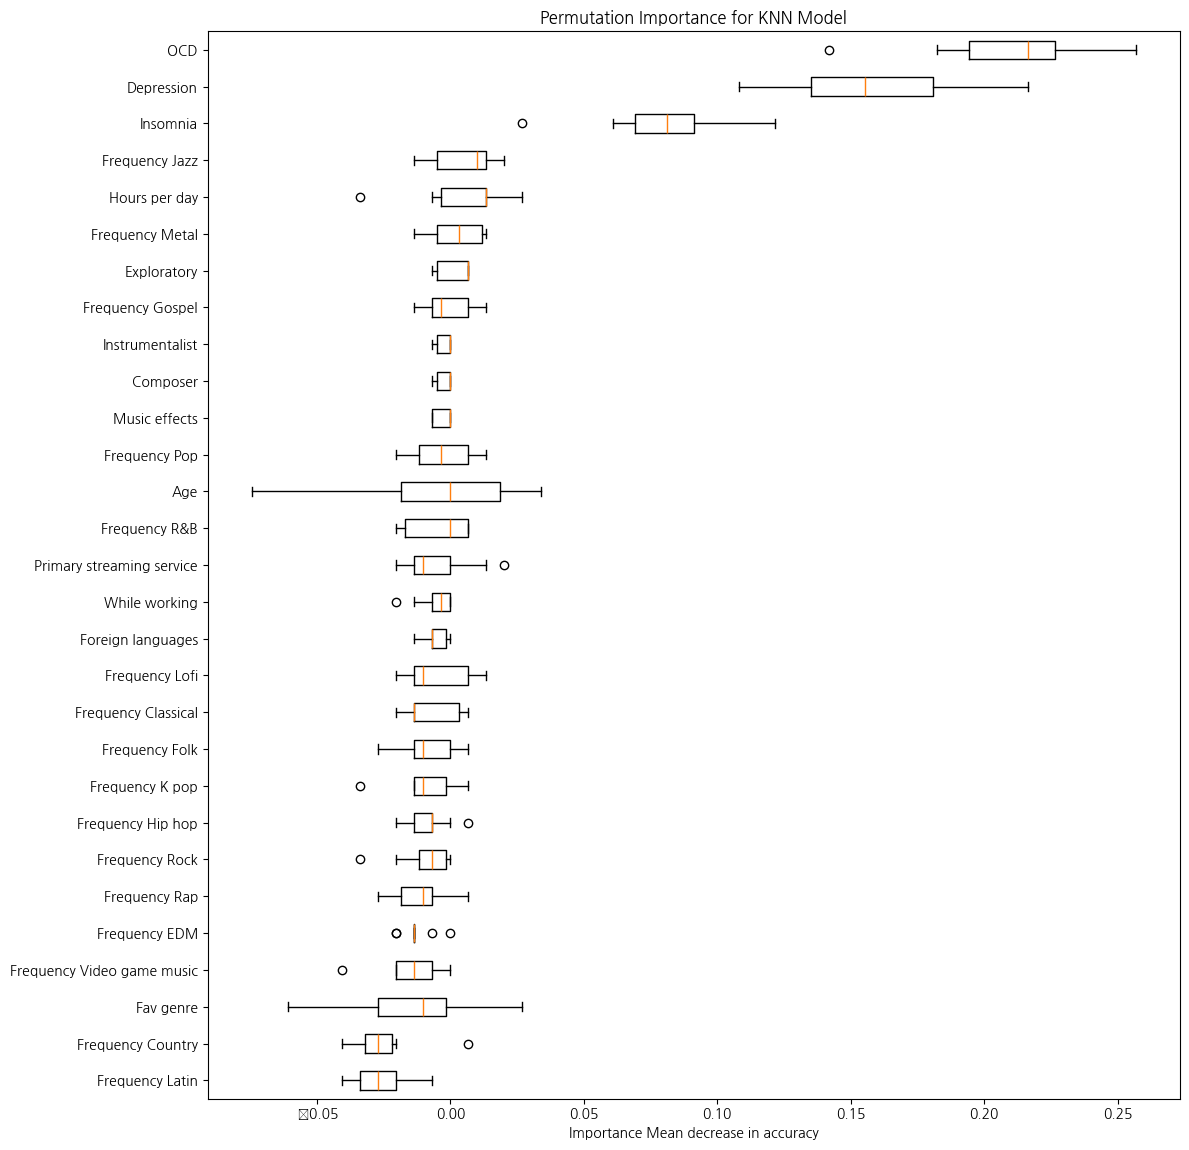

In [50]:
# 시각화
plt.figure(figsize=(12, len(X.columns) * 0.4))
plt.boxplot(result.importances[sorted_idx].T, vert=False, labels=X.columns[sorted_idx])
plt.title("Permutation Importance for KNN Model")
plt.xlabel("Importance Mean decrease in accuracy")
plt.tight_layout()
plt.show()

# 이 코드는 이전에 데이터가 전처리되고 X_train, X_test, y_train, y_test 변수가 정의되었다는 가정 하에 실행됩니다.
# 만약 위의 코드 실행 전에 이 셀만 단독으로 실행한다면, 데이터 로드 및 전처리 부분이 추가되어야 합니다.